**STUDENT_PERFORMANCE_PREDICTION_**


- Understanding the problem statements
- Data Collection
- Data Check and Perform
- EDA
- Data preprocessing and Visulizatons
- Model Trainig
- Cross Validation/Hyper Parameter Tuning
- Choose the Best Model
- Save the Model 

**_Problem Statement_____***

- The main goal of this project is to understand how different factors affect a student's test performance.

- We will study factors such as:
--> according to given dataset.

- The test score is used to measure the student's performance.

__In one simple sentence:__

-- This project analyzes how a student's test score is related to factors like gender, ethnicity, parental education, lunch, and test preparation.

___\\Example:___

-- If students who completed a test preparation course generally get higher scores than students who did not, we can analyze whether there is a relationship between test preparation and student performance.


In [287]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [288]:
df = pd.read_csv("/Users/prem/MLPROJECTS/END_Projects/MLProjectsEND/notebook/data/student_performance_prediction_realistic_.csv")

In [289]:
k = ["shape", "info", "describe", "isnull", "duplicated", "columns", "dtypes"]
for method in k:
    print(f"Method: {method}")
    if method == "shape":
        print(df.shape)
    elif method == "info":
        print(df.info())
    elif method == "describe":
        print(df.describe())
    elif method == "isnull":
        print(df.isnull().sum())
    elif method == "duplicated":
        print(df.duplicated().sum())
    elif method == "columns":
        print(df.columns)
    elif method == "dtypes":
        print(df.dtypes)
    print("\n")

Method: shape
(8000, 21)


Method: info
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           7951 non-null   str    
 1   Age                 8000 non-null   int64  
 2   Gender              8000 non-null   str    
 3   Semester            8000 non-null   int64  
 4   Department          8000 non-null   str    
 5   Attendance          7948 non-null   float64
 6   StudyHours          8000 non-null   float64
 7   AssignmentScore     7943 non-null   float64
 8   MidtermMarks        8000 non-null   int64  
 9   FinalExamMarks      8000 non-null   int64  
 10  SleepHours          8000 non-null   str    
 11  InternetUsageHours  7950 non-null   float64
 12  FamilyIncome        8000 non-null   str    
 13  ParentEducation     6022 non-null   str    
 14  Scholarship         8000 non-null   str    
 15  Hostel              8000 n

In [290]:
df.head()

,StudentID,Age,Gender,Semester,Department,Attendance,StudyHours,AssignmentScore,MidtermMarks,FinalExamMarks,...,InternetUsageHours,FamilyIncome,ParentEducation,Scholarship,Hostel,Extracurricular,PreviousCGPA,ProjectsCompleted,Backlogs,FinalGPA
0,STU100001,23,Male,6,DS,66.0,8.4,50.0,45,21,...,3.0,210151,School,No,Day Scholar,Yes,6.73,6,2,7.45
1,STU100002,22,Male,1,DS,87.0,2.9,54.0,51,-10,...,3.2,210742,NaN,Yes,Day Scholar,Yes,8.45,0,3,6.98
2,STU100003,22,Female,1,ME,53.0,1.7,88.0,63,56,...,6.8,151403,NaN,Yes,Day Scholar,No,7.68,6,0,6.98
3,STU100004,20,Male,4,ME,96.0,5.0,63.0,77,62,...,4.3,88188,Graduate,Yes,Hostel,Yes,6.64,1,2,8.10
4,STU100005,22,Male,1,CE,100.0,4.1,87.0,87,46,...,3.4,47537,NaN,No,Day Scholar,Yes,8.30,8,1,8.59


In [291]:
#--------------------------------
k = ["Gender", "Department", "Semester","ParentEducation", "Scholarship", "Hostel", "Extracurricular" ]

for col in k:
    unique_values = df[col].unique()
    print(f"Column: {col}")
    print(f"Unique Values: {unique_values}")

Column: Gender
Unique Values: <StringArray>
['Male', 'Female', 'male']
Length: 3, dtype: str
Column: Department
Unique Values: <StringArray>
['DS', 'ME', 'CE', 'IT', 'ECE', 'EEE', 'CSE', 'AI&ML']
Length: 8, dtype: str
Column: Semester
Unique Values: [6 1 4 7 2 5 3 8 9]
Column: ParentEducation
Unique Values: <StringArray>
['School', nan, 'Graduate', 'Postgraduate', 'Grad']
Length: 5, dtype: str
Column: Scholarship
Unique Values: <StringArray>
['No', 'Yes', 'Y']
Length: 3, dtype: str
Column: Hostel
Unique Values: <StringArray>
['Day Scholar', 'Hostel', 'hostel']
Length: 3, dtype: str
Column: Extracurricular
Unique Values: <StringArray>
['Yes', 'No', nan]
Length: 3, dtype: str


In [292]:
df.shape

(8000, 21)

In [293]:
df.describe()

,Age,Semester,Attendance,StudyHours,AssignmentScore,MidtermMarks,FinalExamMarks,InternetUsageHours,PreviousCGPA,ProjectsCompleted,FinalGPA
count,8000.000000,8000.000000,7948.000000,8000.000000,7943.000000,8000.000000,8000.000000,7950.000000,8000.000000,8000.000000,8000.000000
mean,21.474125,4.498375,72.732386,4.961062,67.618154,60.769875,59.080375,4.712327,7.445141,3.946875,7.879504
std,2.309112,2.300578,16.061477,2.917936,19.127345,24.216543,23.789597,2.434902,1.432459,2.599932,1.161563
min,18.000000,1.000000,45.000000,-3.000000,35.000000,20.000000,-10.000000,0.500000,5.000000,-1.000000,4.080000
25%,19.000000,3.000000,59.000000,2.500000,51.000000,40.000000,39.000000,2.600000,6.200000,2.000000,7.070000
50%,21.000000,4.000000,73.000000,5.000000,68.000000,61.000000,59.000000,4.700000,7.440000,4.000000,7.865000
75%,23.000000,6.000000,87.000000,7.500000,84.000000,81.000000,79.000000,6.800000,8.650000,6.000000,8.680000
max,25.000000,9.000000,100.000000,10.000000,100.000000,150.000000,100.000000,9.000000,11.500000,8.000000,12.000000


In [294]:
df.isnull().sum() #------------------

StudentID               49
Age                      0
Gender                   0
Semester                 0
Department               0
Attendance              52
StudyHours               0
AssignmentScore         57
MidtermMarks             0
FinalExamMarks           0
SleepHours               0
InternetUsageHours      50
FamilyIncome             0
ParentEducation       1978
Scholarship              0
Hostel                   0
Extracurricular         49
PreviousCGPA             0
ProjectsCompleted        0
Backlogs                 0
FinalGPA                 0
dtype: int64

In [295]:
df.columns

Index(['StudentID', 'Age', 'Gender', 'Semester', 'Department', 'Attendance',
       'StudyHours', 'AssignmentScore', 'MidtermMarks', 'FinalExamMarks',
       'SleepHours', 'InternetUsageHours', 'FamilyIncome', 'ParentEducation',
       'Scholarship', 'Hostel', 'Extracurricular', 'PreviousCGPA',
       'ProjectsCompleted', 'Backlogs', 'FinalGPA'],
      dtype='str')

In [296]:
df.dtypes

StudentID                 str
Age                     int64
Gender                    str
Semester                int64
Department                str
Attendance            float64
StudyHours            float64
AssignmentScore       float64
MidtermMarks            int64
FinalExamMarks          int64
SleepHours                str
InternetUsageHours    float64
FamilyIncome              str
ParentEducation           str
Scholarship               str
Hostel                    str
Extracurricular           str
PreviousCGPA          float64
ProjectsCompleted       int64
Backlogs                  str
FinalGPA              float64
dtype: object

In [297]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           7951 non-null   str    
 1   Age                 8000 non-null   int64  
 2   Gender              8000 non-null   str    
 3   Semester            8000 non-null   int64  
 4   Department          8000 non-null   str    
 5   Attendance          7948 non-null   float64
 6   StudyHours          8000 non-null   float64
 7   AssignmentScore     7943 non-null   float64
 8   MidtermMarks        8000 non-null   int64  
 9   FinalExamMarks      8000 non-null   int64  
 10  SleepHours          8000 non-null   str    
 11  InternetUsageHours  7950 non-null   float64
 12  FamilyIncome        8000 non-null   str    
 13  ParentEducation     6022 non-null   str    
 14  Scholarship         8000 non-null   str    
 15  Hostel              8000 non-null   str    
 16  Extracurricular  

In [298]:
df.duplicated().sum() 

np.int64(0)

In [299]:
df.describe()

,Age,Semester,Attendance,StudyHours,AssignmentScore,MidtermMarks,FinalExamMarks,InternetUsageHours,PreviousCGPA,ProjectsCompleted,FinalGPA
count,8000.000000,8000.000000,7948.000000,8000.000000,7943.000000,8000.000000,8000.000000,7950.000000,8000.000000,8000.000000,8000.000000
mean,21.474125,4.498375,72.732386,4.961062,67.618154,60.769875,59.080375,4.712327,7.445141,3.946875,7.879504
std,2.309112,2.300578,16.061477,2.917936,19.127345,24.216543,23.789597,2.434902,1.432459,2.599932,1.161563
min,18.000000,1.000000,45.000000,-3.000000,35.000000,20.000000,-10.000000,0.500000,5.000000,-1.000000,4.080000
25%,19.000000,3.000000,59.000000,2.500000,51.000000,40.000000,39.000000,2.600000,6.200000,2.000000,7.070000
50%,21.000000,4.000000,73.000000,5.000000,68.000000,61.000000,59.000000,4.700000,7.440000,4.000000,7.865000
75%,23.000000,6.000000,87.000000,7.500000,84.000000,81.000000,79.000000,6.800000,8.650000,6.000000,8.680000
max,25.000000,9.000000,100.000000,10.000000,100.000000,150.000000,100.000000,9.000000,11.500000,8.000000,12.000000


EDA

In [300]:
# Gender
df['Gender'] = df['Gender'].str.strip().str.title()

# Parent Education
df['ParentEducation'] = df['ParentEducation'].replace({
    'Grad': 'Graduate'
})

# Scholarship
df['Scholarship'] = df['Scholarship'].replace({
    'Y': 'Yes'
})

# Hostel
df['Hostel'] = df['Hostel'].str.strip().str.title()

In [301]:
k = ["Gender", "Department", "Semester","ParentEducation", "Scholarship", "Hostel", "Extracurricular" ]

for col in k:
    unique_values = df[col].unique()
    print(f"Column: {col}")
    print(f"Unique Values: {unique_values}")

Column: Gender
Unique Values: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Column: Department
Unique Values: <StringArray>
['DS', 'ME', 'CE', 'IT', 'ECE', 'EEE', 'CSE', 'AI&ML']
Length: 8, dtype: str
Column: Semester
Unique Values: [6 1 4 7 2 5 3 8 9]
Column: ParentEducation
Unique Values: <StringArray>
['School', nan, 'Graduate', 'Postgraduate']
Length: 4, dtype: str
Column: Scholarship
Unique Values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Column: Hostel
Unique Values: <StringArray>
['Day Scholar', 'Hostel']
Length: 2, dtype: str
Column: Extracurricular
Unique Values: <StringArray>
['Yes', 'No', nan]
Length: 3, dtype: str


In [302]:
df.isnull().sum()

StudentID               49
Age                      0
Gender                   0
Semester                 0
Department               0
Attendance              52
StudyHours               0
AssignmentScore         57
MidtermMarks             0
FinalExamMarks           0
SleepHours               0
InternetUsageHours      50
FamilyIncome             0
ParentEducation       1978
Scholarship              0
Hostel                   0
Extracurricular         49
PreviousCGPA             0
ProjectsCompleted        0
Backlogs                 0
FinalGPA                 0
dtype: int64

In [303]:
# ------------- this is for numerical columns
df['Attendance'] = df['Attendance'].fillna(df['Attendance'].median())

df['AssignmentScore'] = df['AssignmentScore'].fillna(df['AssignmentScore'].median())

df['InternetUsageHours'] = df['InternetUsageHours'].fillna(df['InternetUsageHours'].median())

In [304]:
#---------------- this is for categorical columns
df['ParentEducation'] = df['ParentEducation'].fillna(df['ParentEducation'].mode()[0])

df['Extracurricular'] = df['Extracurricular'].fillna(df['Extracurricular'].mode()[0])

In [305]:
df['StudentID'].duplicated().sum()

np.int64(48)

In [306]:
df.isnull().sum()

StudentID             49
Age                    0
Gender                 0
Semester               0
Department             0
Attendance             0
StudyHours             0
AssignmentScore        0
MidtermMarks           0
FinalExamMarks         0
SleepHours             0
InternetUsageHours     0
FamilyIncome           0
ParentEducation        0
Scholarship            0
Hostel                 0
Extracurricular        0
PreviousCGPA           0
ProjectsCompleted      0
Backlogs               0
FinalGPA               0
dtype: int64

In [307]:
df.drop_duplicates(inplace=True)

In [308]:
df.drop('StudentID', axis=1, inplace=True)

In [309]:
df.duplicated().sum()

np.int64(0)

In [310]:
df.isnull().sum()

Age                   0
Gender                0
Semester              0
Department            0
Attendance            0
StudyHours            0
AssignmentScore       0
MidtermMarks          0
FinalExamMarks        0
SleepHours            0
InternetUsageHours    0
FamilyIncome          0
ParentEducation       0
Scholarship           0
Hostel                0
Extracurricular       0
PreviousCGPA          0
ProjectsCompleted     0
Backlogs              0
FinalGPA              0
dtype: int64

<Axes: xlabel='Semester'>

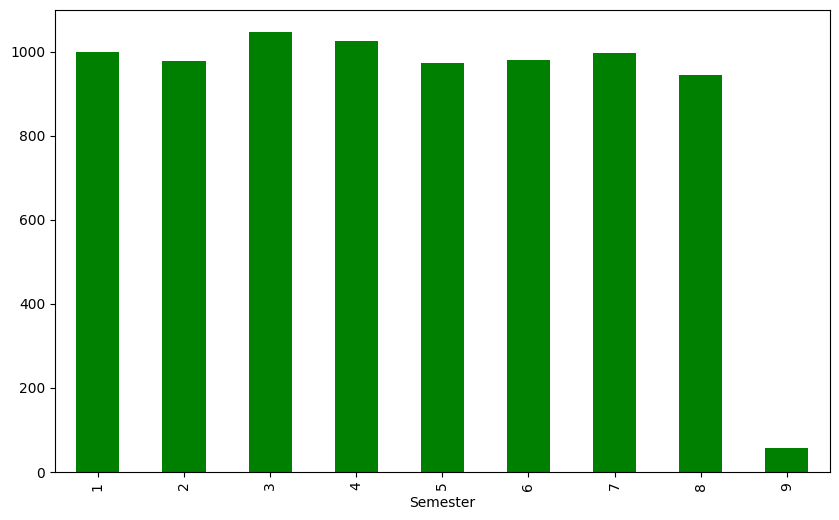

In [311]:
df['Semester'].value_counts().sort_index().plot(kind='bar', figsize=(10, 6), color='Green')


In [312]:
df[df['Semester'] == 9].describe() # in real world sem 9 is nor present

,Age,Semester,Attendance,StudyHours,AssignmentScore,MidtermMarks,FinalExamMarks,InternetUsageHours,PreviousCGPA,ProjectsCompleted,FinalGPA
count,56.000000,56.0,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000
mean,21.535714,9.0,73.678571,5.375000,73.125000,61.589286,59.946429,4.701786,7.583750,4.250000,8.175536
std,2.389099,0.0,15.162282,3.003407,19.249616,23.850120,25.340890,2.494320,1.419346,2.502726,1.254438
min,18.000000,9.0,49.000000,0.300000,36.000000,20.000000,21.000000,0.600000,5.210000,0.000000,5.280000
25%,19.000000,9.0,61.000000,2.525000,60.000000,39.750000,35.500000,2.675000,6.462500,2.000000,7.167500
50%,21.000000,9.0,76.000000,5.750000,80.000000,65.500000,58.000000,4.900000,7.465000,5.000000,8.175000
75%,24.000000,9.0,85.250000,7.825000,89.000000,79.500000,83.500000,6.725000,8.955000,6.000000,9.300000
max,25.000000,9.0,99.000000,9.900000,99.000000,99.000000,100.000000,9.000000,9.770000,8.000000,10.000000


In [313]:
df[df['Semester'] == 9].shape


(56, 20)

In [314]:
df = df[df['Semester'] != 9]

In [315]:
df['Semester'].value_counts().sort_index()

Semester
1     998
2     978
3    1047
4    1025
5     974
6     981
7     996
8     945
Name: count, dtype: int64

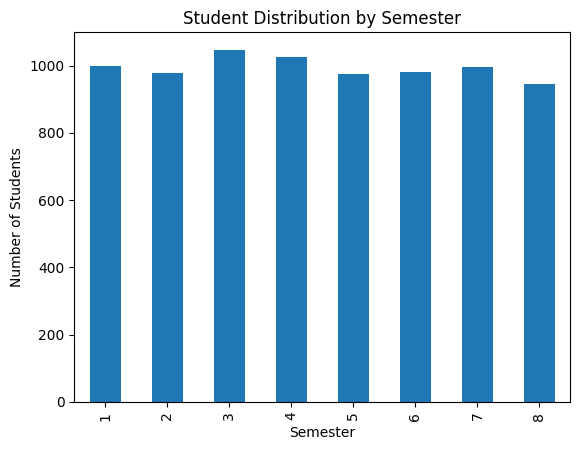

In [316]:
df['Semester'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Semester')
plt.ylabel('Number of Students')
plt.title('Student Distribution by Semester')
plt.show()

In [317]:
df['Age'].describe()

count    7944.000000
mean       21.473691
std         2.308688
min        18.000000
25%        19.000000
50%        21.000000
75%        23.000000
max        25.000000
Name: Age, dtype: float64

In [318]:
df['Attendance'].describe()

count    7944.000000
mean       72.727467
std        16.015717
min        45.000000
25%        59.000000
50%        73.000000
75%        86.000000
max       100.000000
Name: Attendance, dtype: float64

Check Dataset Again

In [319]:
df.info()

<class 'pandas.DataFrame'>
Index: 7944 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 7944 non-null   int64  
 1   Gender              7944 non-null   str    
 2   Semester            7944 non-null   int64  
 3   Department          7944 non-null   str    
 4   Attendance          7944 non-null   float64
 5   StudyHours          7944 non-null   float64
 6   AssignmentScore     7944 non-null   float64
 7   MidtermMarks        7944 non-null   int64  
 8   FinalExamMarks      7944 non-null   int64  
 9   SleepHours          7944 non-null   str    
 10  InternetUsageHours  7944 non-null   float64
 11  FamilyIncome        7944 non-null   str    
 12  ParentEducation     7944 non-null   str    
 13  Scholarship         7944 non-null   str    
 14  Hostel              7944 non-null   str    
 15  Extracurricular     7944 non-null   str    
 16  PreviousCGPA        79

In [320]:
df.isnull().sum()

Age                   0
Gender                0
Semester              0
Department            0
Attendance            0
StudyHours            0
AssignmentScore       0
MidtermMarks          0
FinalExamMarks        0
SleepHours            0
InternetUsageHours    0
FamilyIncome          0
ParentEducation       0
Scholarship           0
Hostel                0
Extracurricular       0
PreviousCGPA          0
ProjectsCompleted     0
Backlogs              0
FinalGPA              0
dtype: int64

In [321]:
df["SleepHours"].unique()

<StringArray>
[  '8.5',   '6.2',   '5.5',   '9.0',   '5.9',   '4.2',   '6.8',   '5.1',
   '8.4',   '6.5',   '8.6',   '7.3',   '7.5',   '7.7',   '7.8',   '6.1',
   '5.6',   '6.6',   '7.1',   '8.8',   '6.3',   '6.9',   '4.5',   '8.9',
   '4.9',   '7.0',   '5.0',   '5.3',   '4.1',   '5.2', 'eight',   '6.4',
   '7.6',   '7.2',   '8.0',   '8.2',   '7.9',   '4.6',   '4.4',   '7.4',
   '8.7',   '4.3',   '4.7',   '8.1',   '4.8',   '4.0',   '6.0',   '6.7',
   '5.8',   '5.7',   '8.3',   '5.4']
Length: 52, dtype: str

In [322]:
df[df['SleepHours'] == 'eight']

,Age,Gender,Semester,Department,Attendance,StudyHours,AssignmentScore,MidtermMarks,FinalExamMarks,SleepHours,InternetUsageHours,FamilyIncome,ParentEducation,Scholarship,Hostel,Extracurricular,PreviousCGPA,ProjectsCompleted,Backlogs,FinalGPA
40,18,Female,4,ECE,61.0,4.3,99.0,41,68,eight,5.9,256648,Graduate,Yes,Day Scholar,No,7.50,7,4,8.60
153,25,Female,4,ME,64.0,0.3,47.0,20,64,eight,1.8,172299,School,Yes,Day Scholar,No,7.16,3,2,6.16
154,19,Female,2,CE,80.0,4.5,49.0,40,96,eight,0.8,35767,School,No,Hostel,No,7.77,5,0,8.40
353,18,Male,4,ME,90.0,5.3,93.0,32,96,eight,1.1,148574,Postgraduate,Yes,Hostel,Yes,8.56,7,3,10.00
572,19,Male,7,DS,69.0,5.9,51.0,97,100,eight,1.2,20003,Postgraduate,No,Hostel,No,6.34,1,1,8.71
688,21,Male,8,ME,61.0,5.9,74.0,87,77,eight,6.5,263660,Graduate,No,Day Scholar,Yes,5.74,2,4,8.49
744,20,Female,2,IT,85.0,4.4,51.0,68,67,eight,5.9,33810,Postgraduate,No,Day Scholar,Yes,9.52,6,4,8.90
1144,23,Female,2,CE,50.0,1.3,36.0,95,51,eight,7.2,128367,Graduate,Yes,Day Scholar,No,5.75,4,0,6.69
1223,24,Male,2,CSE,81.0,8.7,68.0,96,32,eight,8.2,56562,School,Yes,Hostel,Yes,5.84,5,2,7.86
1301,23,Female,1,ECE,92.0,3.8,85.0,47,94,eight,1.4,48917,School,No,Hostel,No,8.11,3,3,8.56


In [323]:
df['SleepHours'] = df['SleepHours'].replace('eight', '8')
df['SleepHours'] = pd.to_numeric(df['SleepHours'])

In [324]:
df['SleepHours'].dtype

dtype('float64')

In [325]:
df['SleepHours'].unique()

array([8.5, 6.2, 5.5, 9. , 5.9, 4.2, 6.8, 5.1, 8.4, 6.5, 8.6, 7.3, 7.5,
       7.7, 7.8, 6.1, 5.6, 6.6, 7.1, 8.8, 6.3, 6.9, 4.5, 8.9, 4.9, 7. ,
       5. , 5.3, 4.1, 5.2, 8. , 6.4, 7.6, 7.2, 8.2, 7.9, 4.6, 4.4, 7.4,
       8.7, 4.3, 4.7, 8.1, 4.8, 4. , 6. , 6.7, 5.8, 5.7, 8.3, 5.4])

In [326]:
df["FamilyIncome"].unique()

<StringArray>
['210151', '210742', '151403',  '88188',  '47537', '263128',  '80877',
  '20484',  '57515', '116676',
 ...
 '129207', '219289',  '97484', '290099', '155859',  '99344',  '27438',
 '269995', '171573', '188603']
Length: 7776, dtype: str

In [327]:
df["FamilyIncome"].describe()

count        7944
unique       7776
top       unknown
freq           57
Name: FamilyIncome, dtype: object

In [328]:
df["FamilyIncome"] = pd.to_numeric(
    df["FamilyIncome"],
    errors="coerce"
)

In [329]:
df["FamilyIncome"].describe()

count      7887.000000
mean     159378.162419
std       81810.385487
min       15036.000000
25%       87913.000000
50%      161081.000000
75%      229585.000000
max      299980.000000
Name: FamilyIncome, dtype: float64

In [330]:
df["FamilyIncome"].dtype

dtype('float64')

In [331]:
df["FamilyIncome"].unique()

array([210151., 210742., 151403., ..., 269995., 171573., 188603.],
      shape=(7776,))

In [332]:
df["Backlogs"].unique()

<StringArray>
['2', '3', '0', '1', '4', '?']
Length: 6, dtype: str

In [333]:
df["Backlogs"].describe()

count     7944
unique       6
top          2
freq      1639
Name: Backlogs, dtype: object

In [334]:
import numpy as np

df['Backlogs'] = df['Backlogs'].replace('?', np.nan)

df['Backlogs'] = pd.to_numeric(df['Backlogs'])

In [335]:
df['Backlogs'].unique()

array([ 2.,  3.,  0.,  1.,  4., nan])

In [336]:
df['Backlogs'] = df['Backlogs'].fillna(df['Backlogs'].median())

In [337]:
df['Backlogs'].isnull().sum()

np.int64(0)

In [338]:
df['Backlogs'].unique().dtype

dtype('float64')

In [339]:
df['Backlogs'] = df['Backlogs'].astype(int)

In [340]:
df['Backlogs'].unique().dtype

dtype('int64')

In [341]:
df['Backlogs'].unique()

array([2, 3, 0, 1, 4])

In [342]:
df.info()

<class 'pandas.DataFrame'>
Index: 7944 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 7944 non-null   int64  
 1   Gender              7944 non-null   str    
 2   Semester            7944 non-null   int64  
 3   Department          7944 non-null   str    
 4   Attendance          7944 non-null   float64
 5   StudyHours          7944 non-null   float64
 6   AssignmentScore     7944 non-null   float64
 7   MidtermMarks        7944 non-null   int64  
 8   FinalExamMarks      7944 non-null   int64  
 9   SleepHours          7944 non-null   float64
 10  InternetUsageHours  7944 non-null   float64
 11  FamilyIncome        7887 non-null   float64
 12  ParentEducation     7944 non-null   str    
 13  Scholarship         7944 non-null   str    
 14  Hostel              7944 non-null   str    
 15  Extracurricular     7944 non-null   str    
 16  PreviousCGPA        79

In [343]:
df.isnull().sum()

Age                    0
Gender                 0
Semester               0
Department             0
Attendance             0
StudyHours             0
AssignmentScore        0
MidtermMarks           0
FinalExamMarks         0
SleepHours             0
InternetUsageHours     0
FamilyIncome          57
ParentEducation        0
Scholarship            0
Hostel                 0
Extracurricular        0
PreviousCGPA           0
ProjectsCompleted      0
Backlogs               0
FinalGPA               0
dtype: int64

In [344]:
df['FamilyIncome'] = df['FamilyIncome'].fillna(df['FamilyIncome'].median())


In [345]:
df.isnull().sum()

Age                   0
Gender                0
Semester              0
Department            0
Attendance            0
StudyHours            0
AssignmentScore       0
MidtermMarks          0
FinalExamMarks        0
SleepHours            0
InternetUsageHours    0
FamilyIncome          0
ParentEducation       0
Scholarship           0
Hostel                0
Extracurricular       0
PreviousCGPA          0
ProjectsCompleted     0
Backlogs              0
FinalGPA              0
dtype: int64

In [346]:
df.info()


<class 'pandas.DataFrame'>
Index: 7944 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 7944 non-null   int64  
 1   Gender              7944 non-null   str    
 2   Semester            7944 non-null   int64  
 3   Department          7944 non-null   str    
 4   Attendance          7944 non-null   float64
 5   StudyHours          7944 non-null   float64
 6   AssignmentScore     7944 non-null   float64
 7   MidtermMarks        7944 non-null   int64  
 8   FinalExamMarks      7944 non-null   int64  
 9   SleepHours          7944 non-null   float64
 10  InternetUsageHours  7944 non-null   float64
 11  FamilyIncome        7944 non-null   float64
 12  ParentEducation     7944 non-null   str    
 13  Scholarship         7944 non-null   str    
 14  Hostel              7944 non-null   str    
 15  Extracurricular     7944 non-null   str    
 16  PreviousCGPA        79

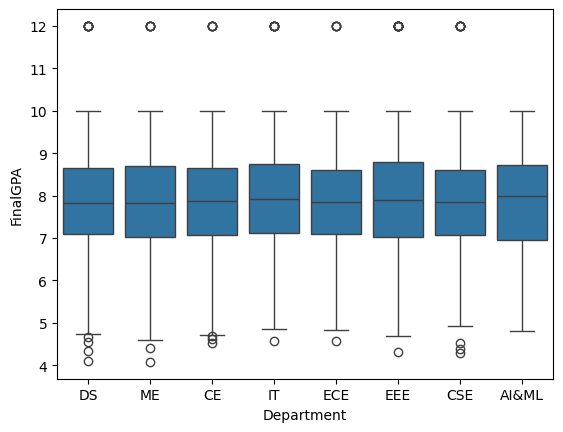

In [347]:
sns.boxplot(x='Department', y='FinalGPA', data=df)
plt.show()

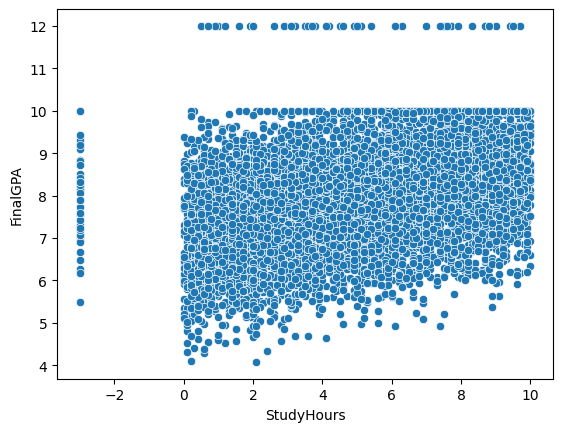

In [348]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x='StudyHours', y='FinalGPA', data=df)
plt.show()

In [349]:
df.corr(numeric_only=True)

,Age,Semester,Attendance,StudyHours,AssignmentScore,MidtermMarks,FinalExamMarks,SleepHours,InternetUsageHours,FamilyIncome,PreviousCGPA,ProjectsCompleted,Backlogs,FinalGPA
Age,1.000000,-0.005148,0.019682,-0.008122,0.013036,-0.020566,-0.024765,0.001359,0.002811,0.003807,-0.030070,-0.018412,0.025992,-0.035305
Semester,-0.005148,1.000000,-0.003648,0.010208,-0.000168,0.015136,-0.000826,0.000306,0.012224,-0.005313,0.004717,-0.002873,0.009367,0.014045
Attendance,0.019682,-0.003648,1.000000,-0.002578,0.013248,-0.000232,-0.001500,-0.021636,0.001706,-0.034342,-0.006562,-0.009161,0.004370,0.241961
StudyHours,-0.008122,0.010208,-0.002578,1.000000,-0.000228,0.009633,-0.014949,0.011194,0.015542,-0.010276,-0.005697,-0.011199,-0.000875,0.386447
AssignmentScore,0.013036,-0.000168,0.013248,-0.000228,1.000000,0.028847,0.013076,-0.004949,-0.003970,0.012048,-0.016360,-0.020165,0.020263,0.295653
MidtermMarks,-0.020566,0.015136,-0.000232,0.009633,0.028847,1.000000,-0.001044,0.003440,-0.001932,0.003196,-0.022501,0.030306,0.008735,0.348267
FinalExamMarks,-0.024765,-0.000826,-0.001500,-0.014949,0.013076,-0.001044,1.000000,0.010191,0.003366,-0.007954,0.010078,0.003065,0.003534,0.522580
SleepHours,0.001359,0.000306,-0.021636,0.011194,-0.004949,0.003440,0.010191,1.000000,-0.016572,0.005749,-0.002168,-0.010604,0.010644,0.109525
InternetUsageHours,0.002811,0.012224,0.001706,0.015542,-0.003970,-0.001932,0.003366,-0.016572,1.000000,0.009816,-0.019564,-0.008661,0.016534,-0.080521
FamilyIncome,0.003807,-0.005313,-0.034342,-0.010276,0.012048,0.003196,-0.007954,0.005749,0.009816,1.000000,0.017007,-0.007501,0.016637,-0.008281


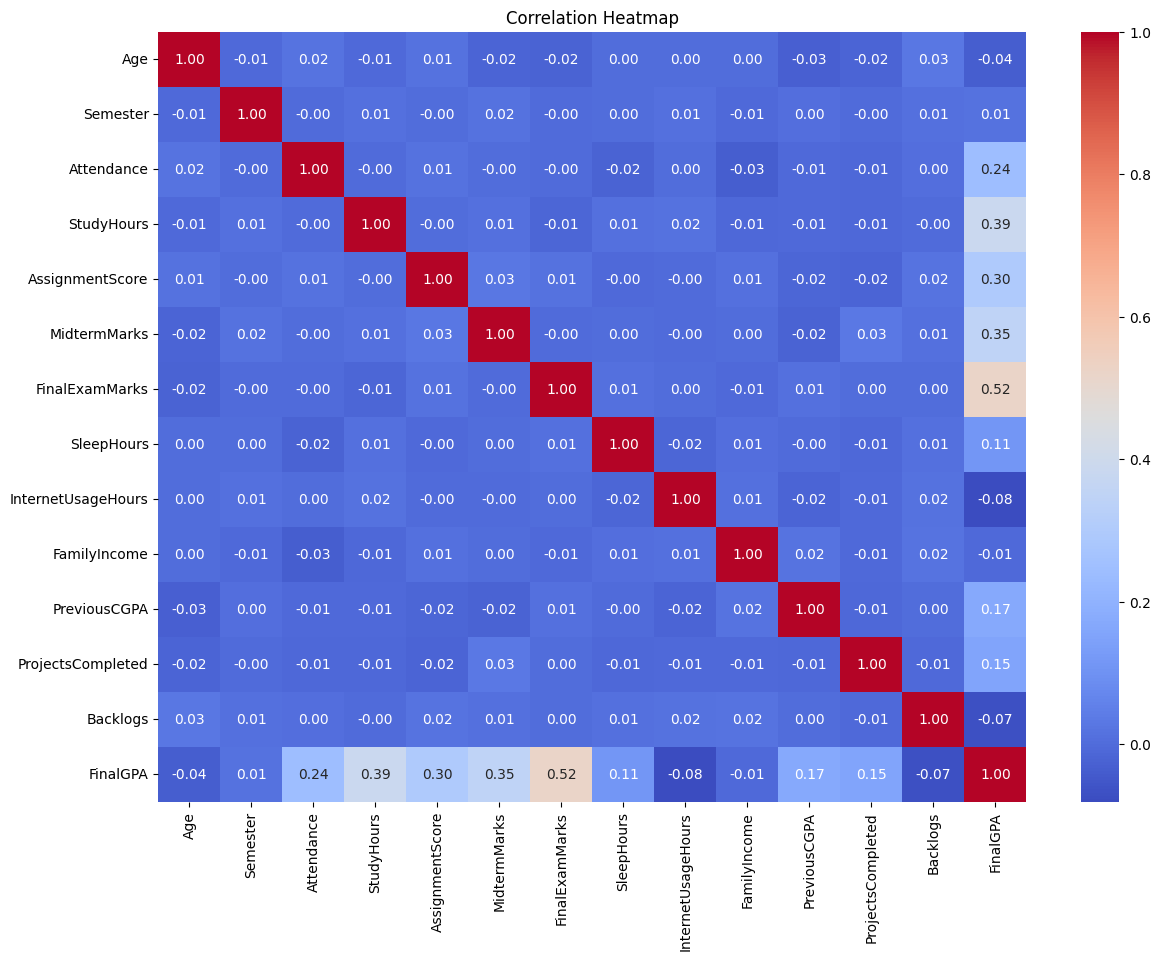

In [350]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [351]:
corr = df.corr(numeric_only=True)

high = corr.where(
    (corr.abs() >= 0.5) & (corr.abs() < 1)
).stack().reset_index()

high.columns = ['Feature 1', 'Feature 2', 'Correlation']

low = corr.where(
    corr.abs() < 0.3
).stack().reset_index()

low.columns = ['Feature 1', 'Feature 2', 'Correlation']

print("HIGH CORRELATION")
display(high)

print("LOW CORRELATION")
display(low)

HIGH CORRELATION


,Feature 1,Feature 2,Correlation
0,Age,Age,NaN
1,Age,Semester,NaN
2,Age,Attendance,NaN
3,Age,StudyHours,NaN
4,Age,AssignmentScore,NaN
...,...,...,...
191,FinalGPA,FamilyIncome,NaN
192,FinalGPA,PreviousCGPA,NaN
193,FinalGPA,ProjectsCompleted,NaN
194,FinalGPA,Backlogs,NaN


LOW CORRELATION


,Feature 1,Feature 2,Correlation
0,Age,Age,NaN
1,Age,Semester,-0.005148
2,Age,Attendance,0.019682
3,Age,StudyHours,-0.008122
4,Age,AssignmentScore,0.013036
...,...,...,...
191,FinalGPA,FamilyIncome,-0.008281
192,FinalGPA,PreviousCGPA,0.170451
193,FinalGPA,ProjectsCompleted,0.154089
194,FinalGPA,Backlogs,-0.069704


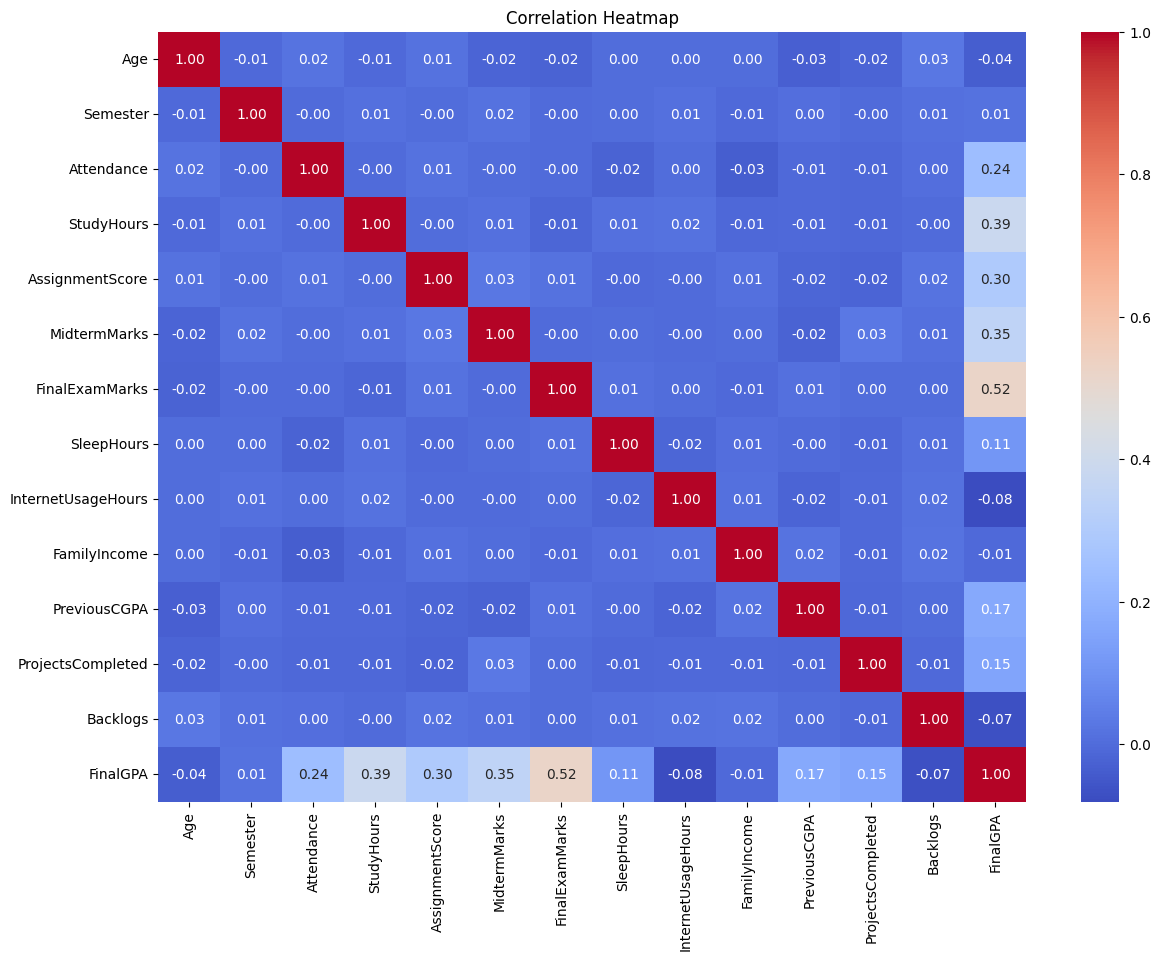

In [352]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [353]:
corr = df.corr(numeric_only=True)['FinalGPA'].sort_values(ascending=False)

print(corr)

FinalGPA              1.000000
FinalExamMarks        0.522580
StudyHours            0.386447
MidtermMarks          0.348267
AssignmentScore       0.295653
Attendance            0.241961
PreviousCGPA          0.170451
ProjectsCompleted     0.154089
SleepHours            0.109525
Semester              0.014045
FamilyIncome         -0.008281
Age                  -0.035305
Backlogs             -0.069704
InternetUsageHours   -0.080521
Name: FinalGPA, dtype: float64


In [354]:
high_relation = corr[abs(corr) >= 0.5]

low_relation = corr[abs(corr) < 0.3]

print("HIGH RELATION")
print(high_relation)

print("\nLOW RELATION")
print(low_relation)

HIGH RELATION
FinalGPA          1.00000
FinalExamMarks    0.52258
Name: FinalGPA, dtype: float64

LOW RELATION
AssignmentScore       0.295653
Attendance            0.241961
PreviousCGPA          0.170451
ProjectsCompleted     0.154089
SleepHours            0.109525
Semester              0.014045
FamilyIncome         -0.008281
Age                  -0.035305
Backlogs             -0.069704
InternetUsageHours   -0.080521
Name: FinalGPA, dtype: float64


In [355]:
corr = df.corr(numeric_only=True)['FinalGPA'].drop('FinalGPA')

In [356]:
high_relation = corr[abs(corr) >= 0.5].sort_values(ascending=False)

low_relation = corr[abs(corr) < 0.3].sort_values(ascending=False)

In [357]:
high_table = high_relation.reset_index()
high_table.columns = ['Feature', 'Correlation']

low_table = low_relation.reset_index()
low_table.columns = ['Feature', 'Correlation']

print("HIGH RELATION")
display(high_table)

print("LOW RELATION")
display(low_table)

HIGH RELATION


,Feature,Correlation
0,FinalExamMarks,0.52258


LOW RELATION


,Feature,Correlation
0,AssignmentScore,0.295653
1,Attendance,0.241961
2,PreviousCGPA,0.170451
3,ProjectsCompleted,0.154089
4,SleepHours,0.109525
5,Semester,0.014045
6,FamilyIncome,-0.008281
7,Age,-0.035305
8,Backlogs,-0.069704
9,InternetUsageHours,-0.080521


In [358]:
df.info()

<class 'pandas.DataFrame'>
Index: 7944 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 7944 non-null   int64  
 1   Gender              7944 non-null   str    
 2   Semester            7944 non-null   int64  
 3   Department          7944 non-null   str    
 4   Attendance          7944 non-null   float64
 5   StudyHours          7944 non-null   float64
 6   AssignmentScore     7944 non-null   float64
 7   MidtermMarks        7944 non-null   int64  
 8   FinalExamMarks      7944 non-null   int64  
 9   SleepHours          7944 non-null   float64
 10  InternetUsageHours  7944 non-null   float64
 11  FamilyIncome        7944 non-null   float64
 12  ParentEducation     7944 non-null   str    
 13  Scholarship         7944 non-null   str    
 14  Hostel              7944 non-null   str    
 15  Extracurricular     7944 non-null   str    
 16  PreviousCGPA        79

In [359]:
# 1. Average of Assignment and Midterm marks
df["AverageMarks"] = (
    df["AssignmentScore"] +
    df["MidtermMarks"]
) / 2


# 2. Study and Sleep relationship
df["StudySleepRatio"] = (
    df["StudyHours"] /
    (df["SleepHours"] + 1)
)


# 3. Internet usage compared with study hours
df["InternetStudyRatio"] = (
    df["InternetUsageHours"] /
    (df["StudyHours"] + 1)
)


# 4. Whether student has any backlog
df["HasBacklog"] = (
    df["Backlogs"] > 0
).astype(int)


# 5. Whether student has completed any project
df["HasProject"] = (
    df["ProjectsCompleted"] > 0
).astype(int)

In [360]:
target = "FinalGPA"

numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_features.remove(target)

categorical_features = df.select_dtypes(include=["object", "category"]).columns.tolist()

In [361]:
target_col = "FinalGPA"

Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_count = ((df[target_col] < lower) | (df[target_col] > upper)).sum()
outlier_percentage = round((outlier_count / len(df)) * 100, 2)

target_outlier_df = pd.DataFrame({
    "Feature": [target_col],
    "Q1": [round(Q1, 2)],
    "Q3": [round(Q3, 2)],
    "IQR": [round(IQR, 2)],
    "Lower_Bound": [round(lower, 2)],
    "Upper_Bound": [round(upper, 2)],
    "Outlier_Count": [outlier_count],
    "Outlier_Percentage (%)": [outlier_percentage]
})

target_outlier_df

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage (%)
0,FinalGPA,7.07,8.67,1.6,4.67,11.08,63,0.79


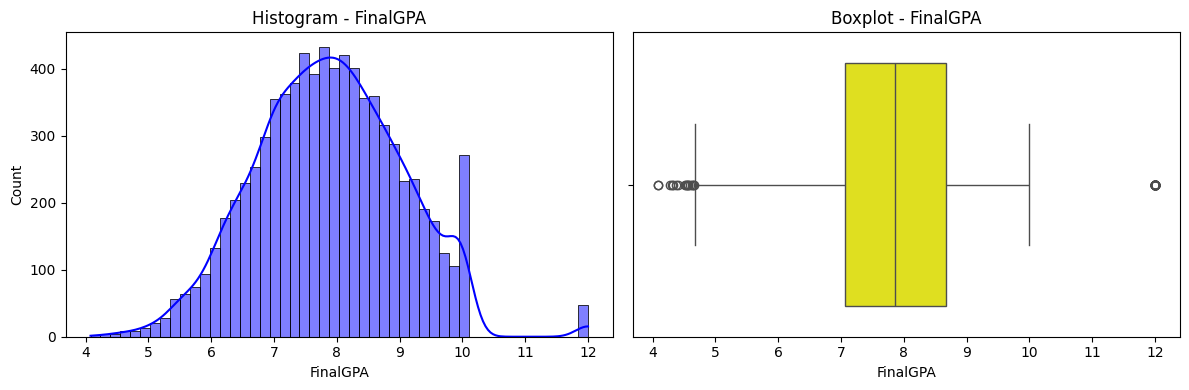

In [362]:
target_col = "FinalGPA"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
sns.histplot(df[target_col], kde=True, ax=axes[0], color="blue",edgecolor="black")
axes[0].set_title(f"Histogram - {target_col}")

# Boxplot
sns.boxplot(x=df[target_col], ax=axes[1], color="yellow")
axes[1].set_title(f"Boxplot - {target_col}")

plt.tight_layout()
plt.show()

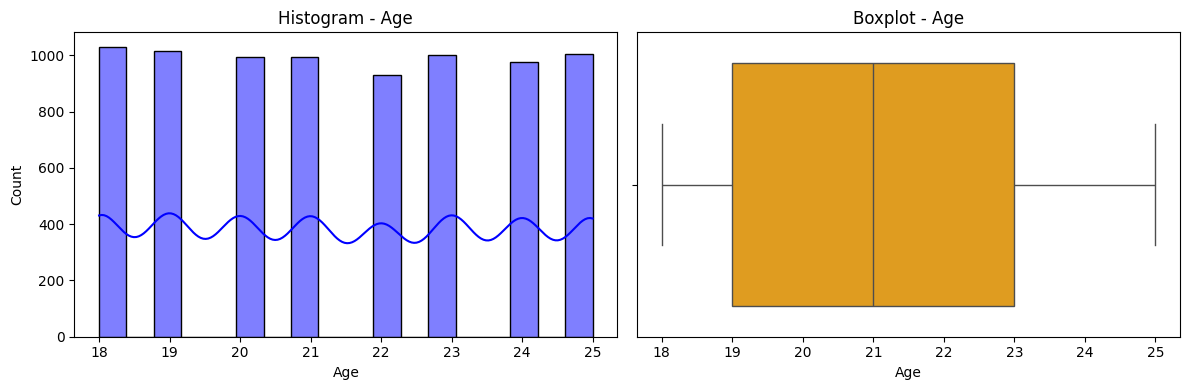

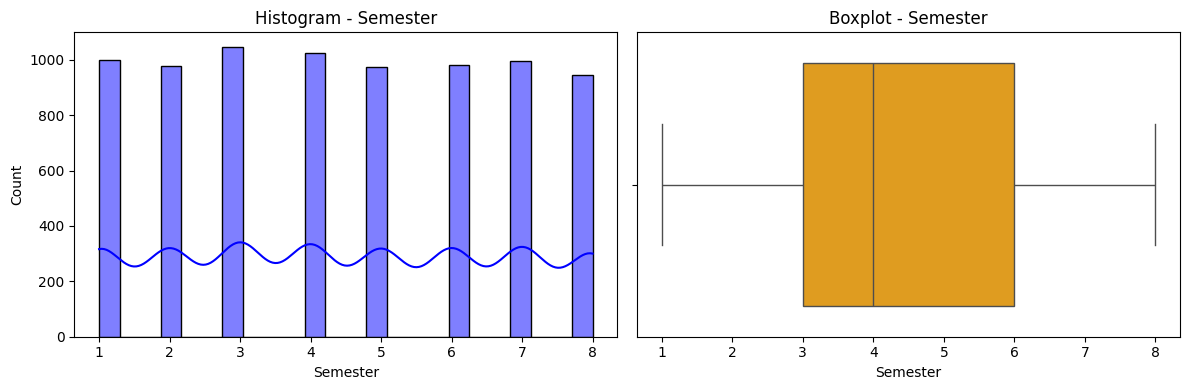

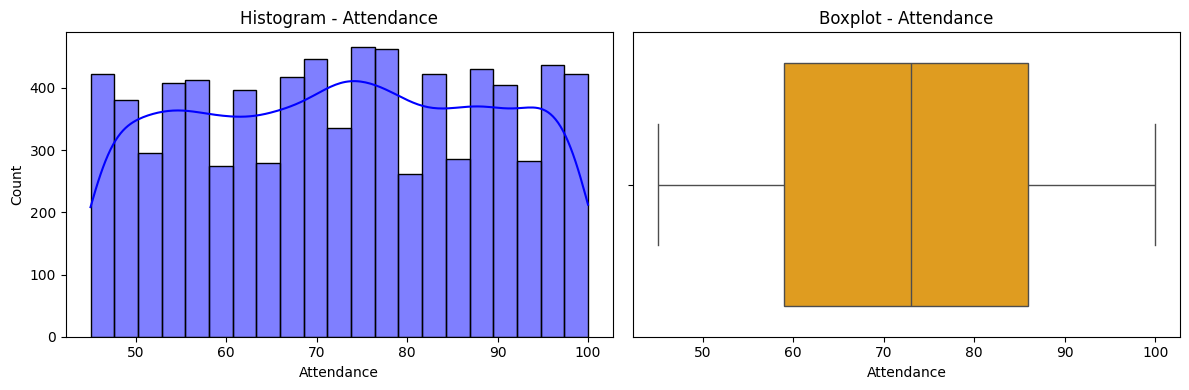

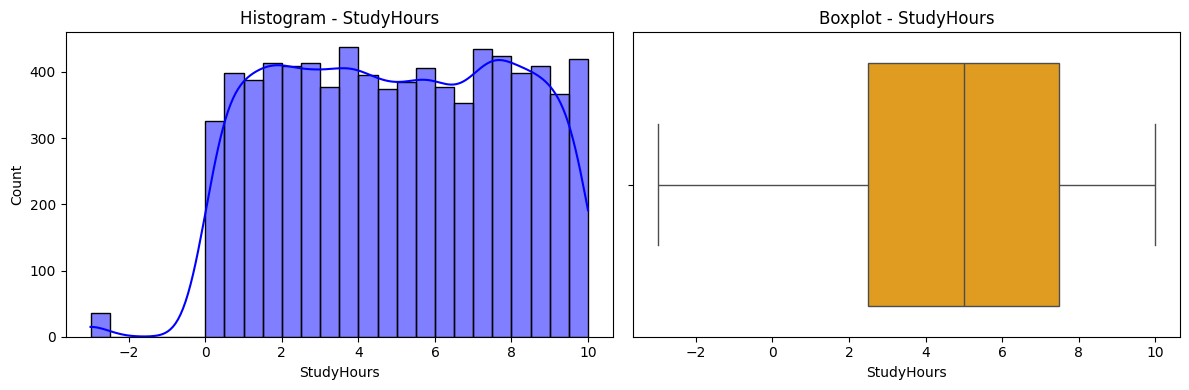

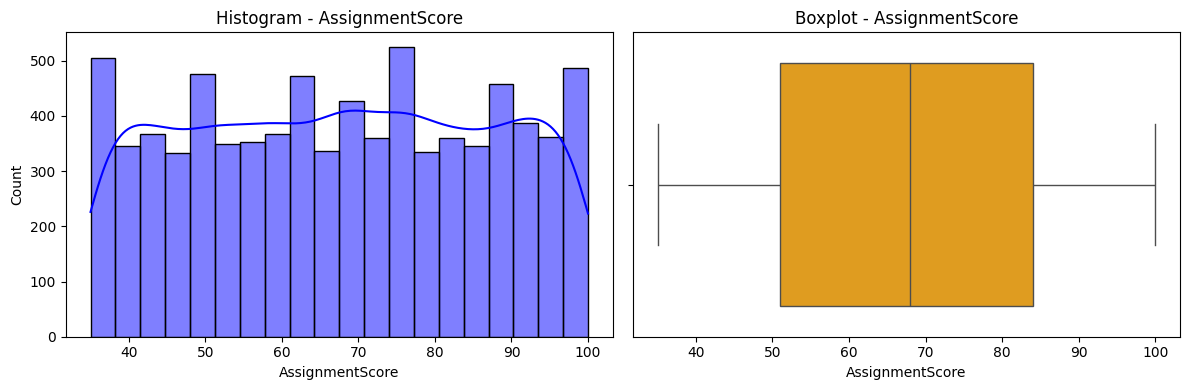

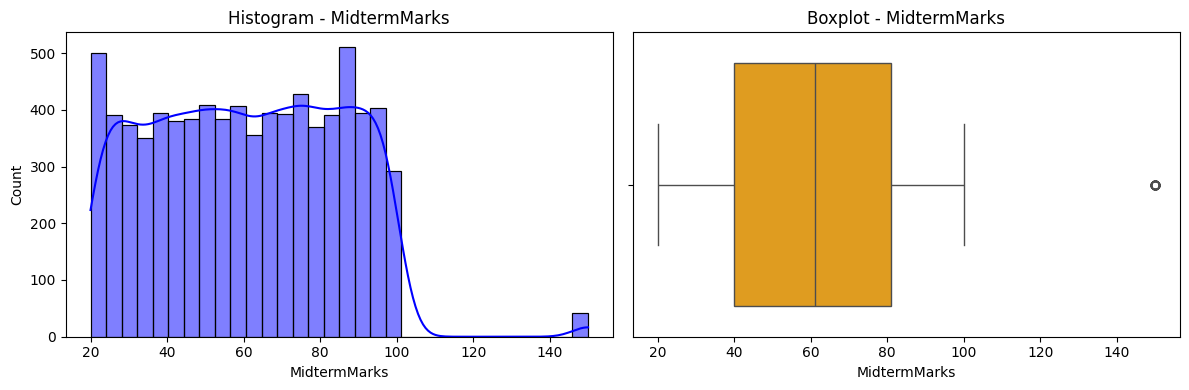

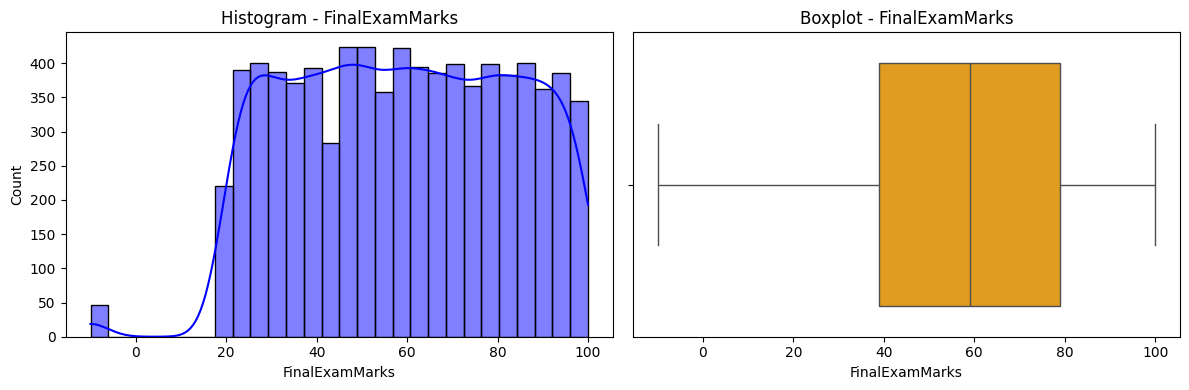

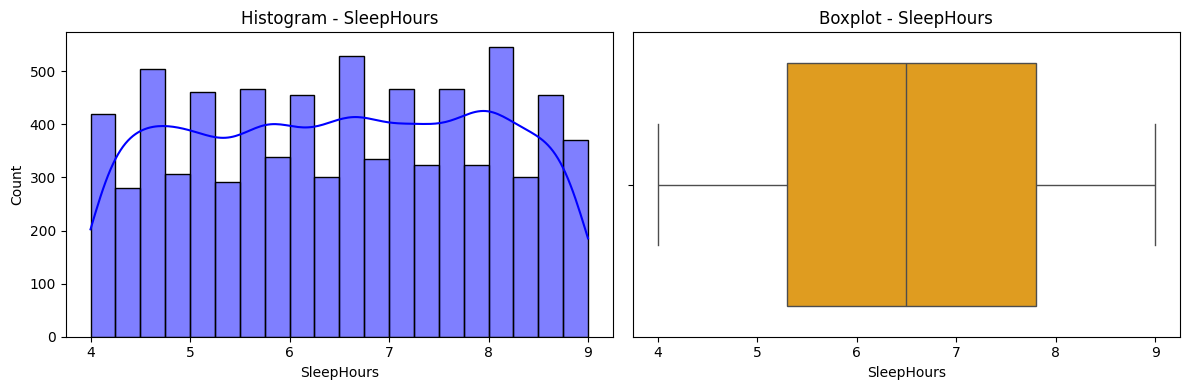

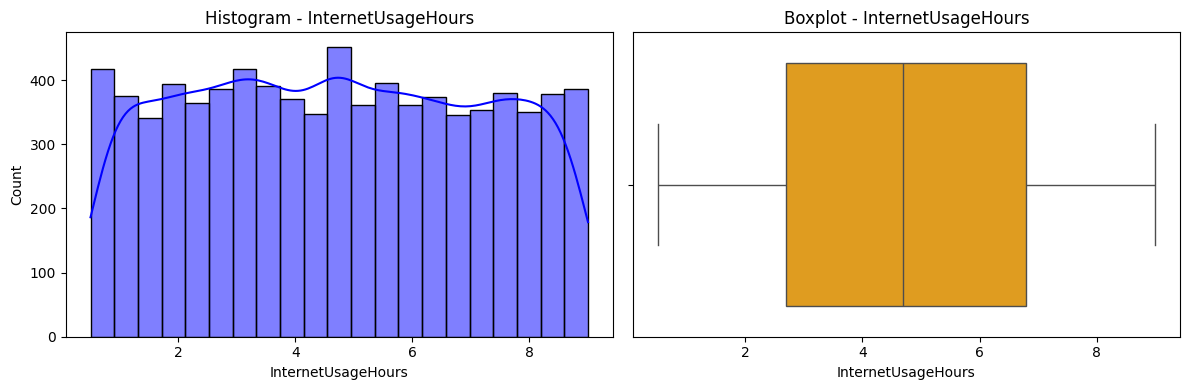

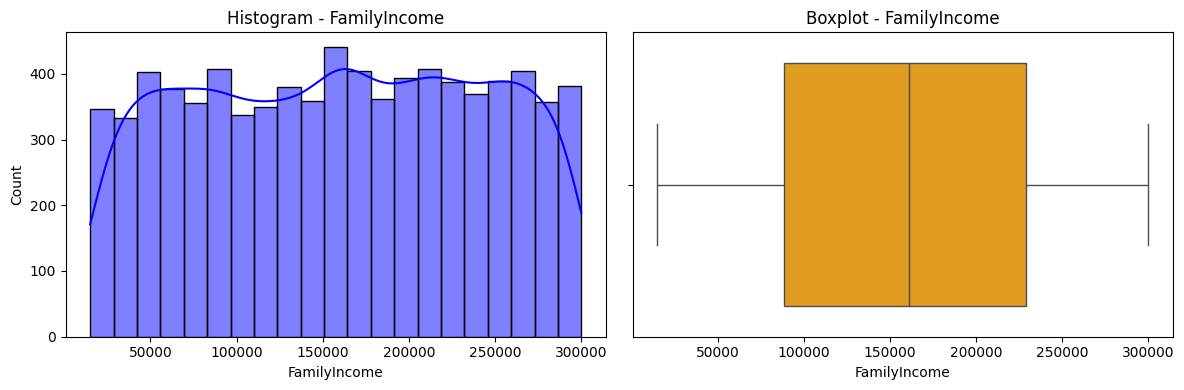

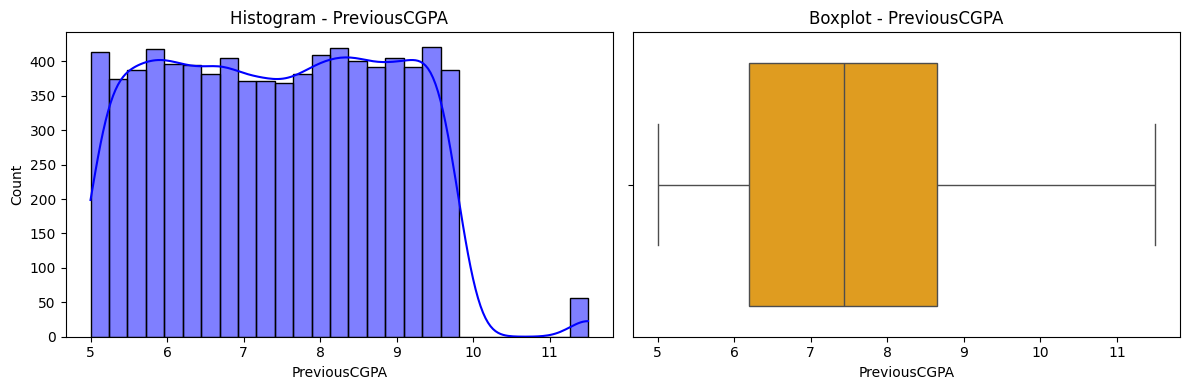

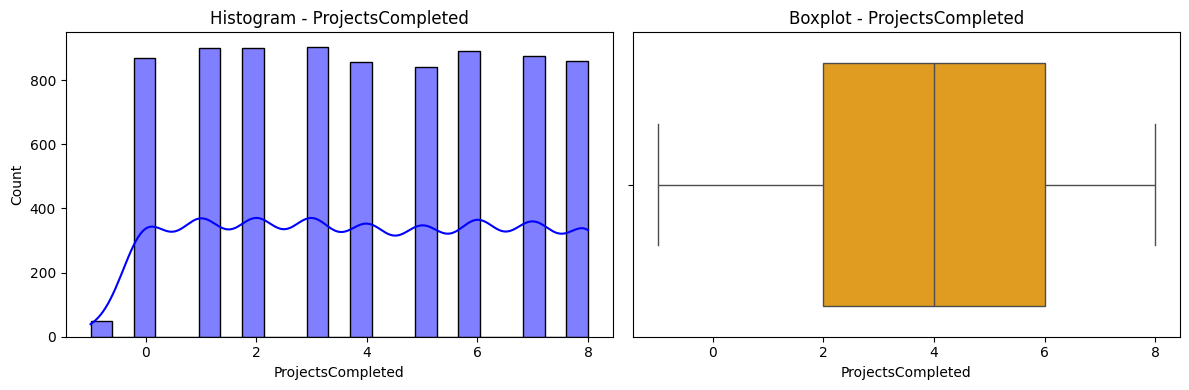

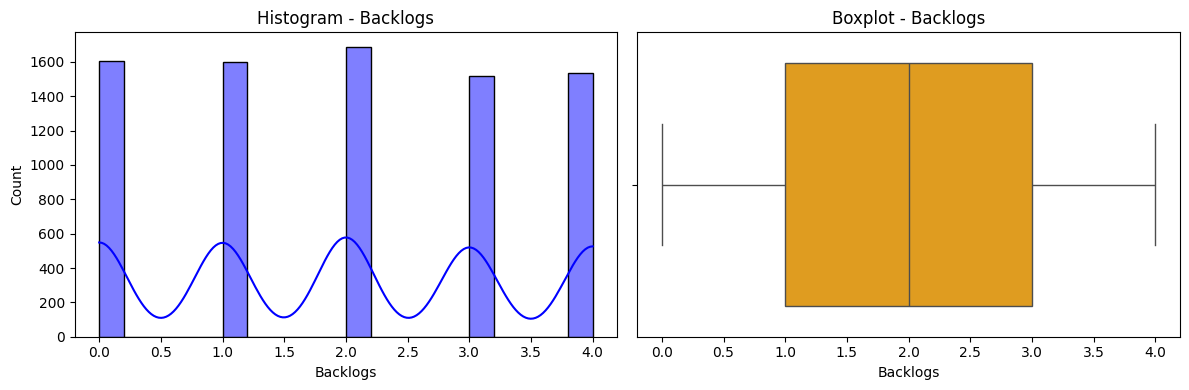

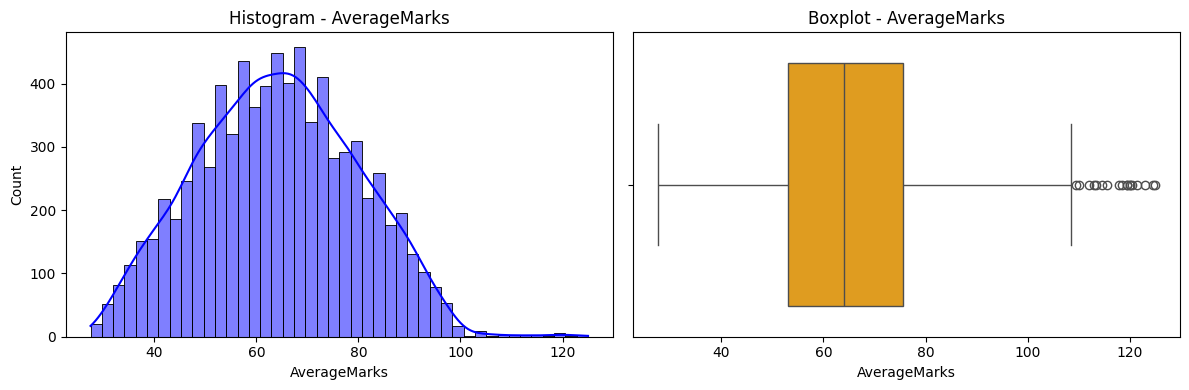

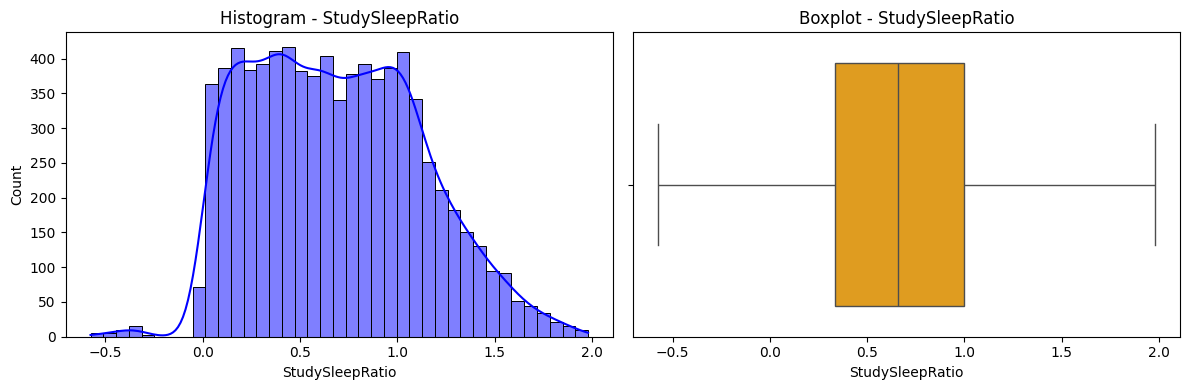

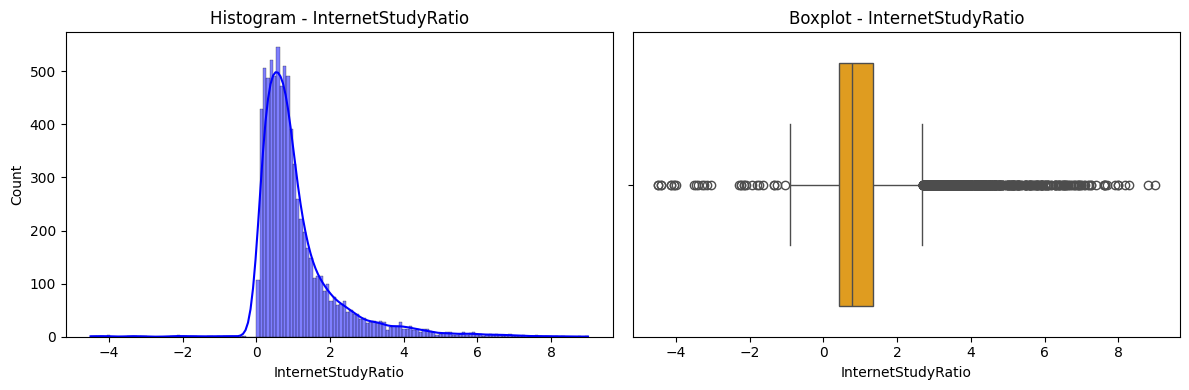

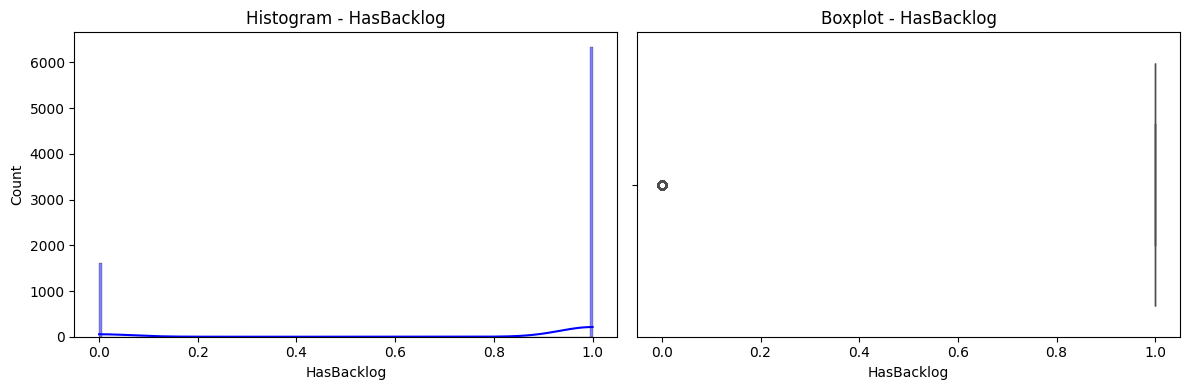

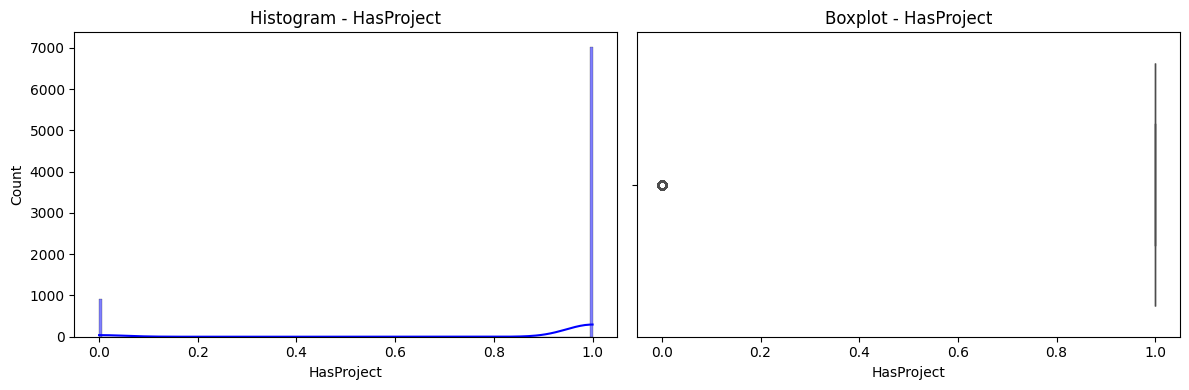

In [363]:
import matplotlib.pyplot as plt
import seaborn as sns

# ତୁମେ ଆଗରୁ ତିଆରି କରିଥିବା Numeric Features List
for col in numeric_features:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0], color="blue",edgecolor="black")
    axes[0].set_title(f"Histogram - {col}")

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1], color="orange")
    axes[1].set_title(f"Boxplot - {col}")

    plt.tight_layout()
    plt.show()

In [364]:
skew_df = (
    df[numeric_features]
    .skew()
    .sort_values(ascending=False)
    .reset_index()
)

skew_df.columns = ["Feature", "Skewness"]

skew_df

,Feature,Skewness
0,InternetStudyRatio,2.122208
1,StudySleepRatio,0.299574
2,MidtermMarks,0.181327
3,PreviousCGPA,0.092481
4,AverageMarks,0.091224
5,Backlogs,0.028943
6,InternetUsageHours,0.027258
7,Semester,0.020285
8,Age,0.016900
9,ProjectsCompleted,0.009941


In [365]:
df["AverageMarks"] = (
    df["AssignmentScore"] +
    df["MidtermMarks"]
) / 2

In [366]:
numeric_features

['Age',
 'Semester',
 'Attendance',
 'StudyHours',
 'AssignmentScore',
 'MidtermMarks',
 'FinalExamMarks',
 'SleepHours',
 'InternetUsageHours',
 'FamilyIncome',
 'PreviousCGPA',
 'ProjectsCompleted',
 'Backlogs',
 'AverageMarks',
 'StudySleepRatio',
 'InternetStudyRatio',
 'HasBacklog',
 'HasProject']

In [367]:
categorical_features

['Gender',
 'Department',
 'ParentEducation',
 'Scholarship',
 'Hostel',
 'Extracurricular']

In [368]:
target

'FinalGPA'

In [369]:
df.shape # -- after cleaning all 

(7944, 25)

In [371]:
features_col = numeric_features + categorical_features

X = df[features_col]
y = df["FinalGPA"]

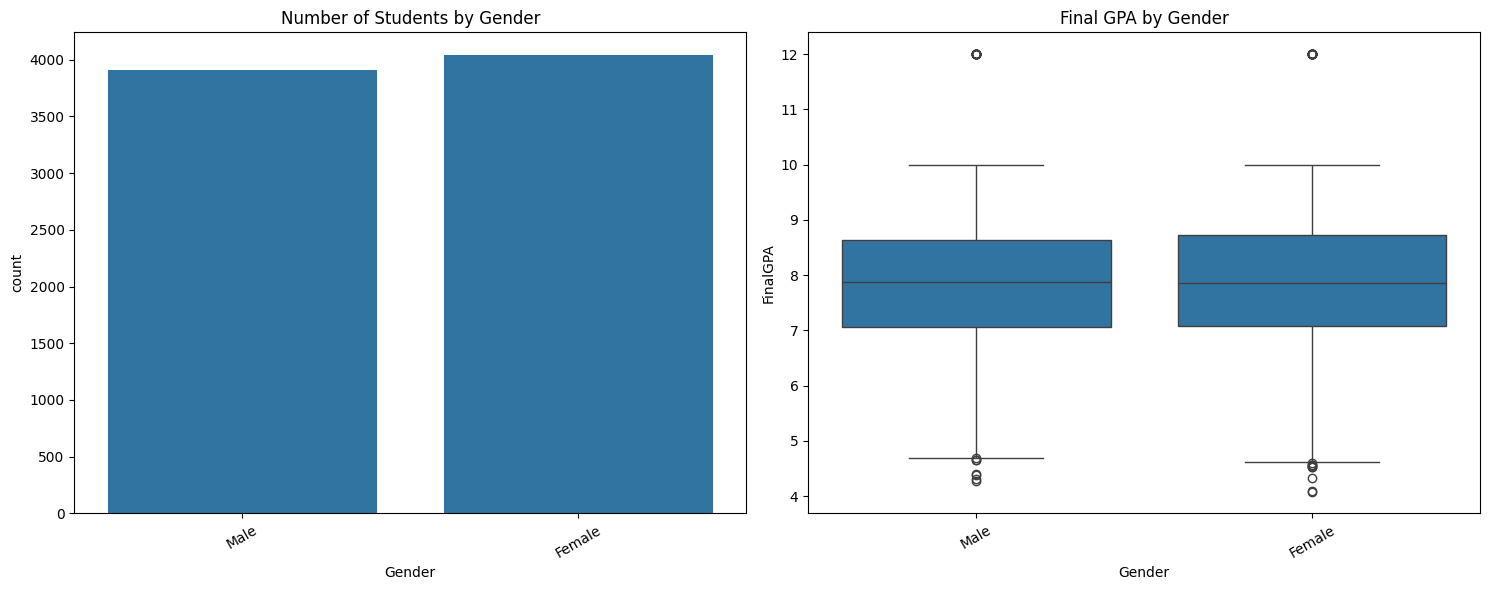

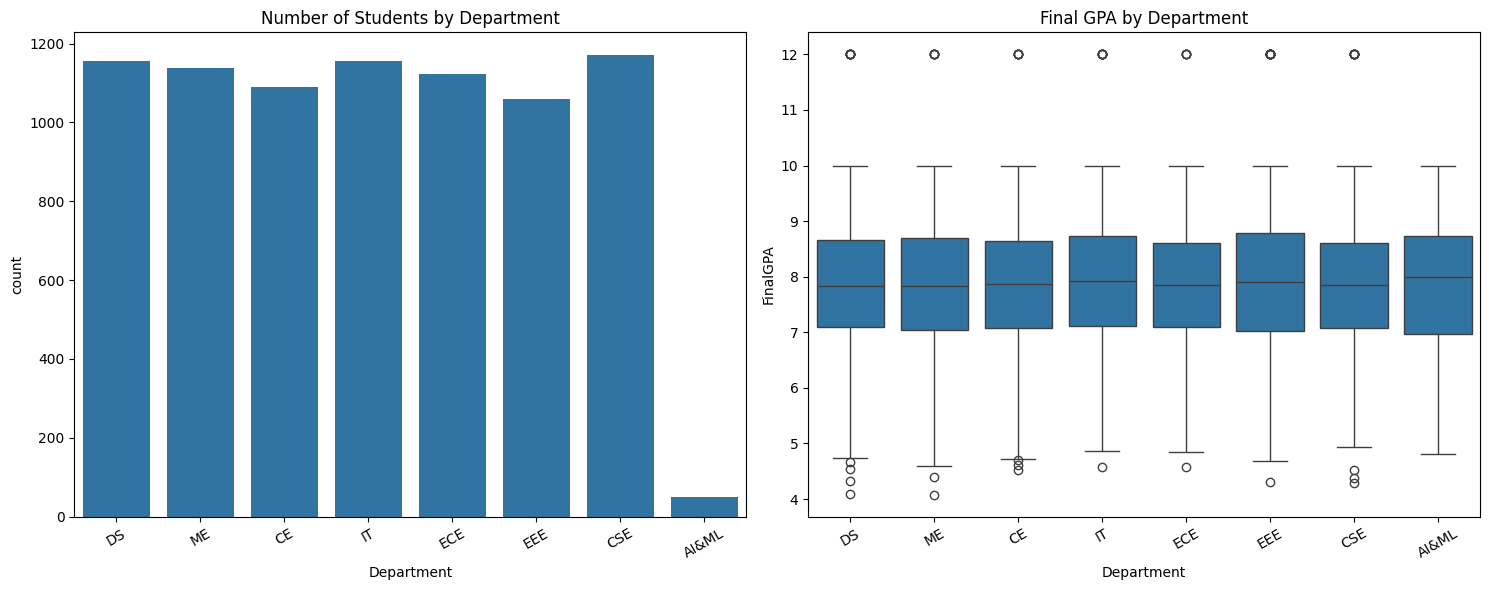

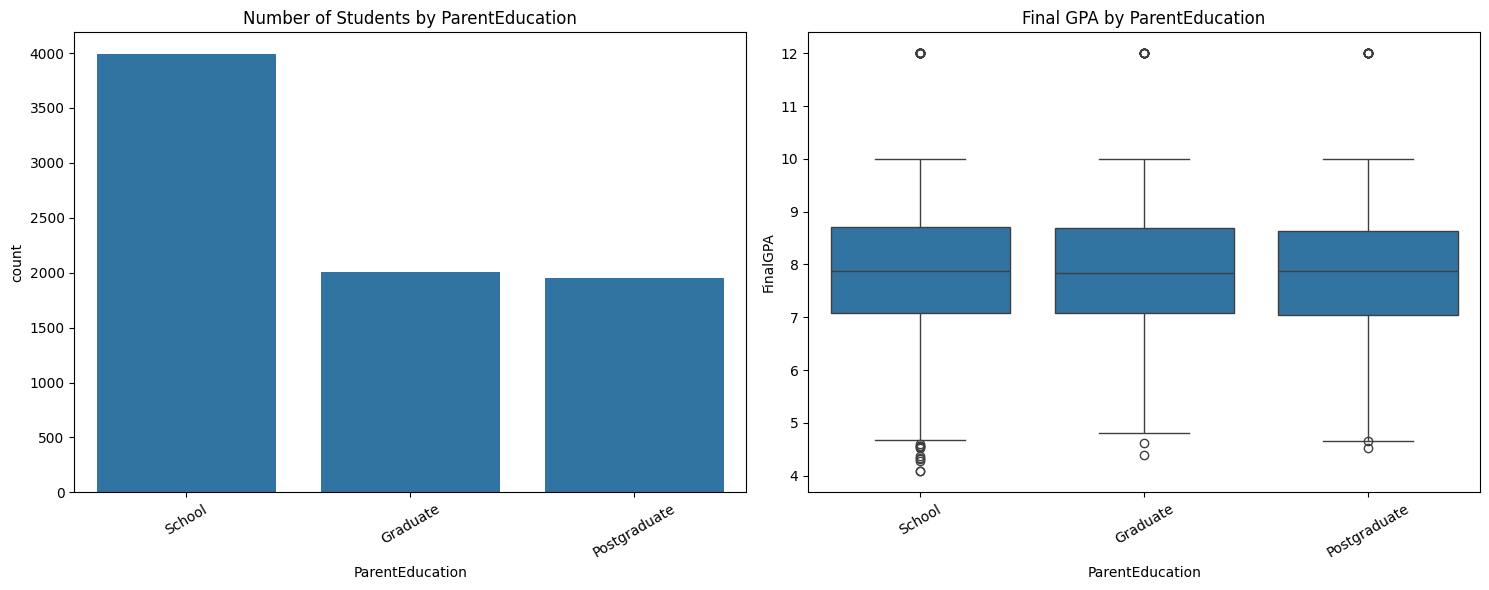

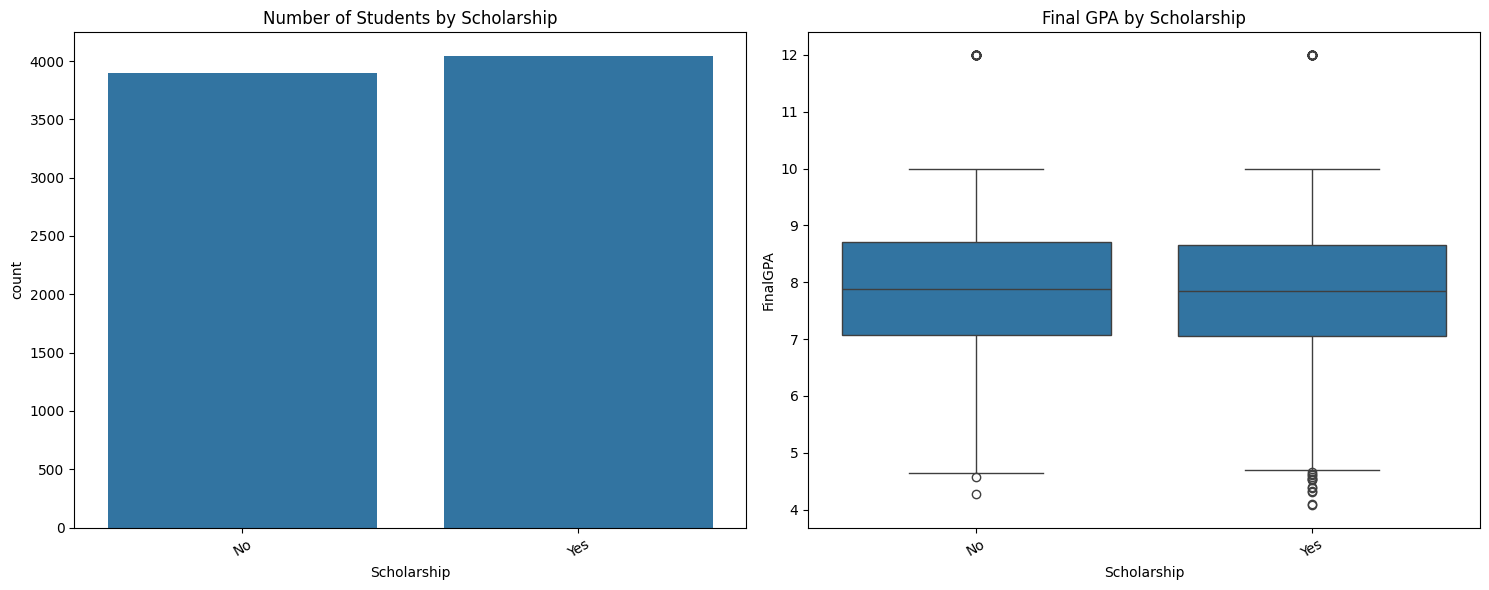

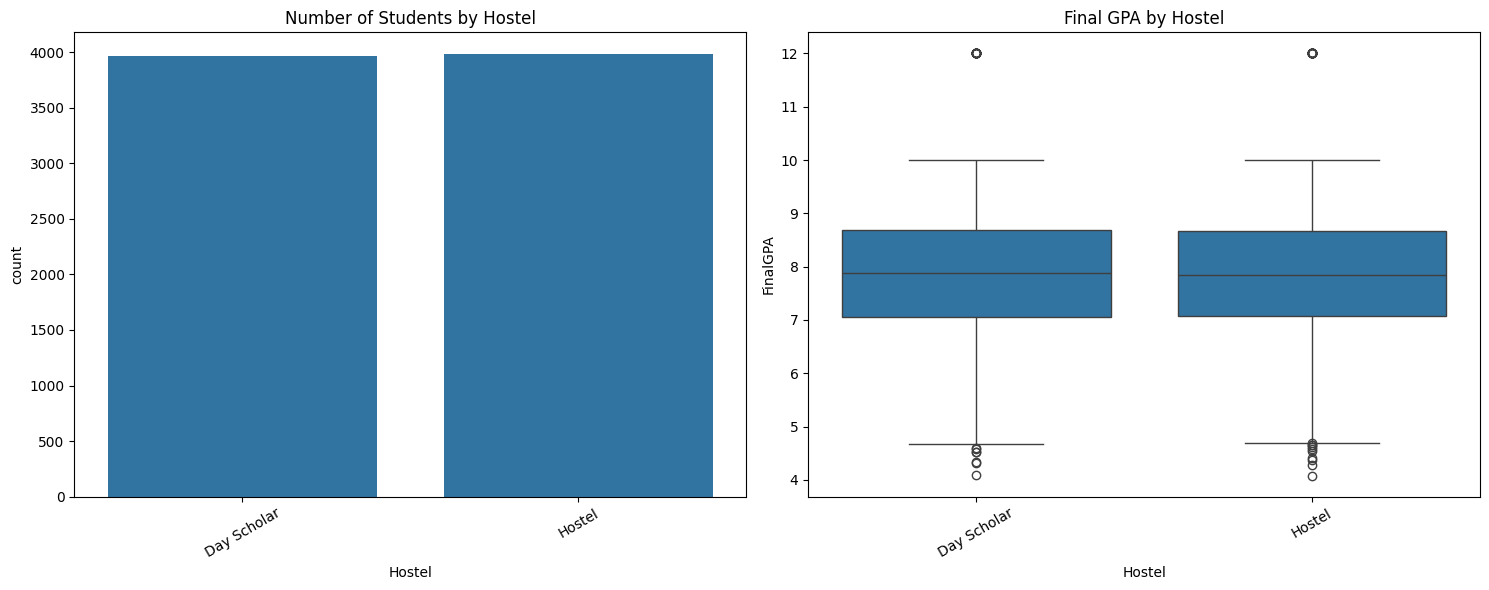

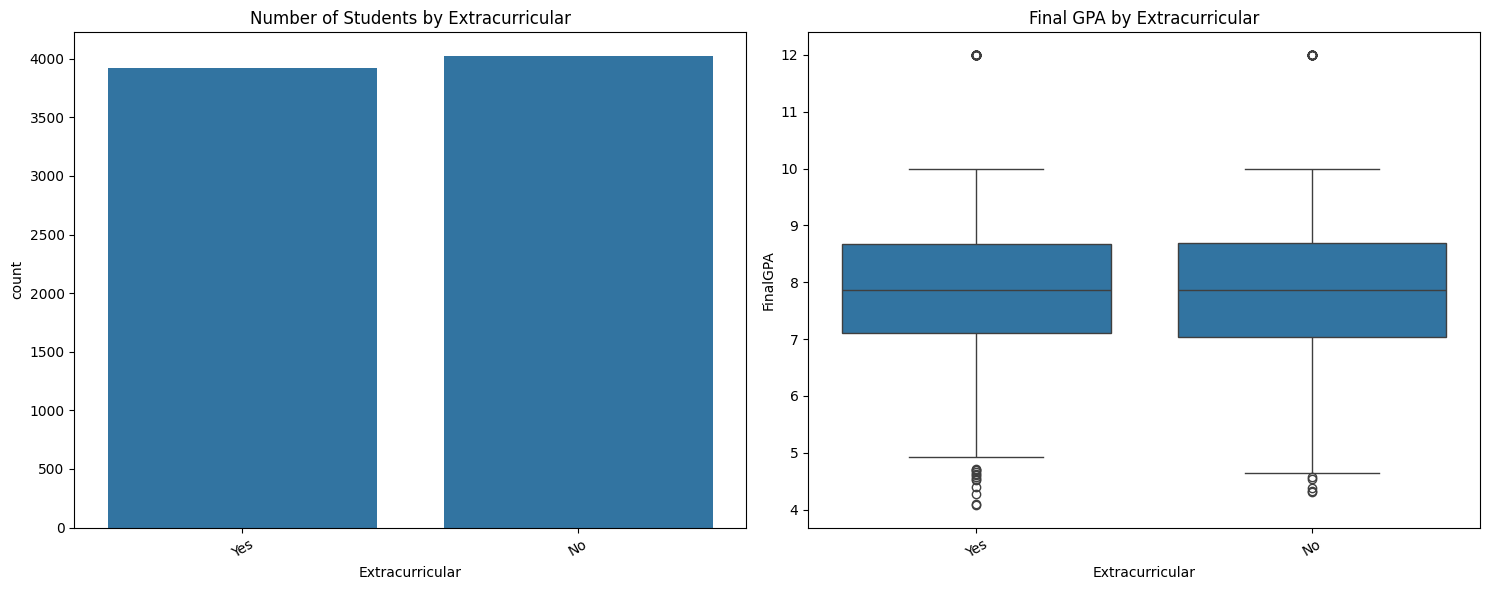

In [377]:
for col in categorical_features:

    fig, axs = plt.subplots(1, 2, figsize=(15, 6))

    # Quantity
    sns.countplot(
        data=df,
        x=col,
        ax=axs[0]
    )

    axs[0].set_title(f"Number of Students by {col}")
    axs[0].tick_params(axis='x', rotation=30)

    # Performance
    sns.boxplot(
        data=df,
        x=col,
        y='FinalGPA',
        ax=axs[1]
    )

    axs[1].set_title(f"Final GPA by {col}")
    axs[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

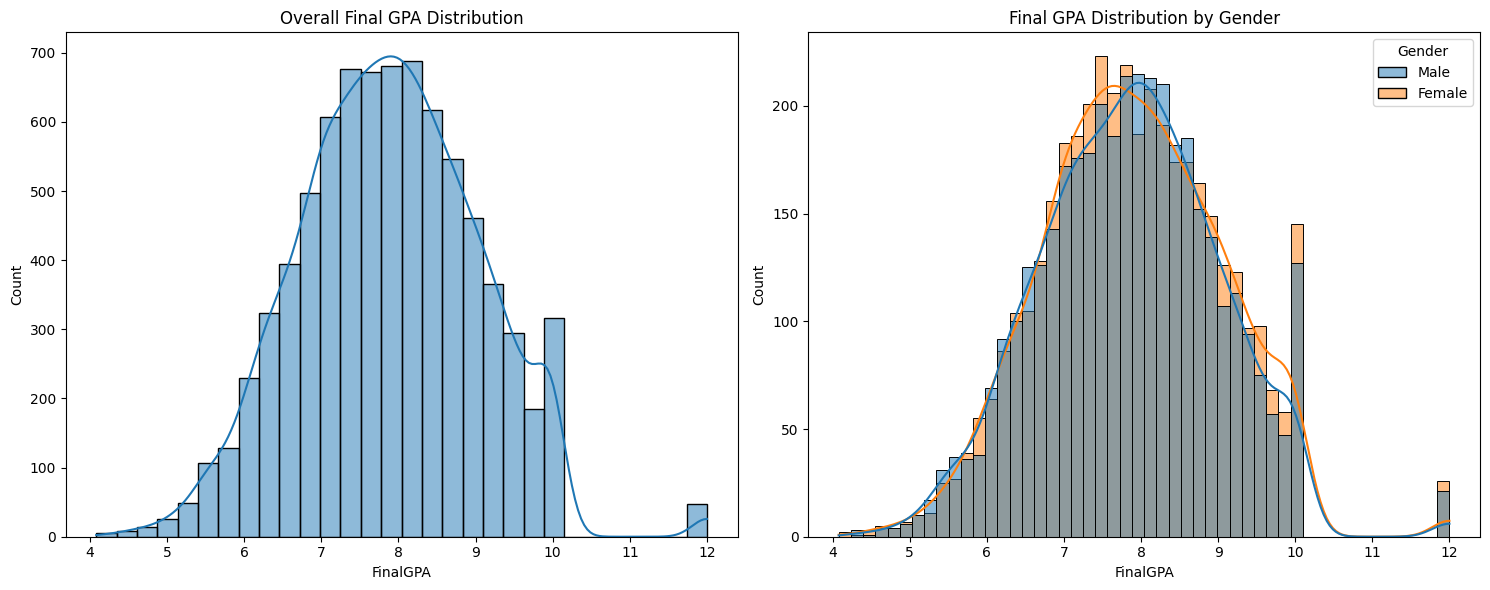

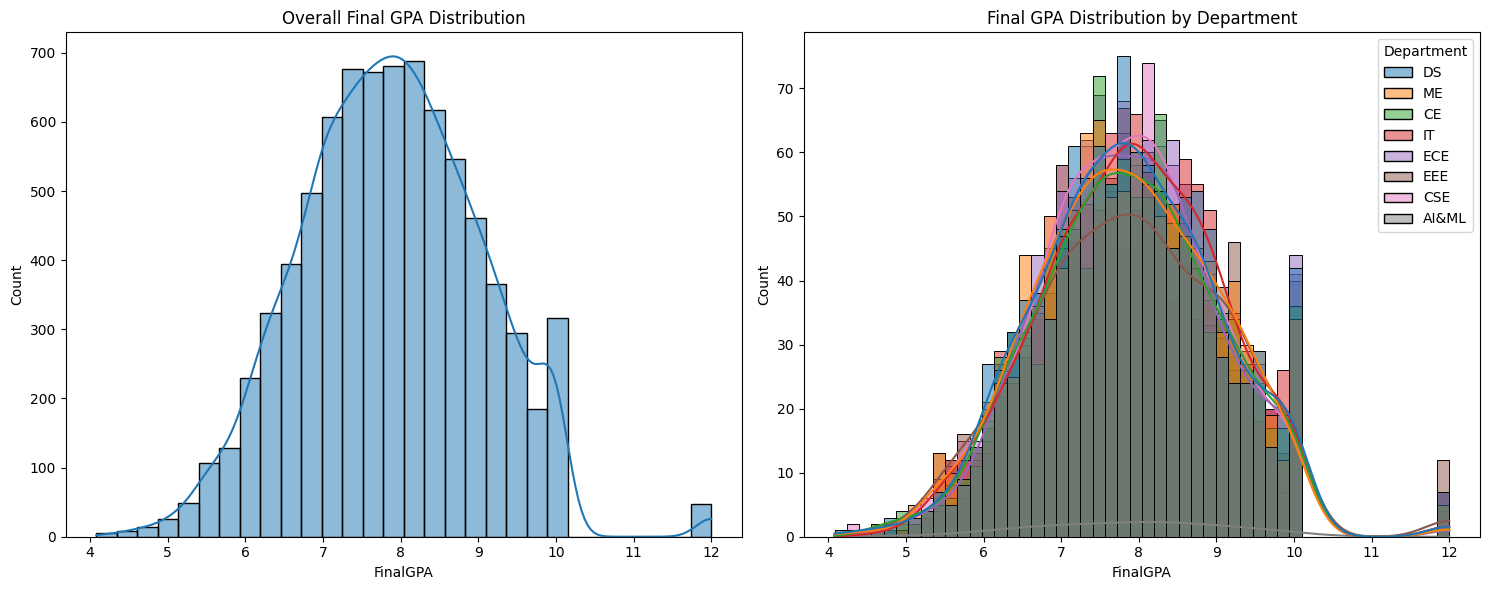

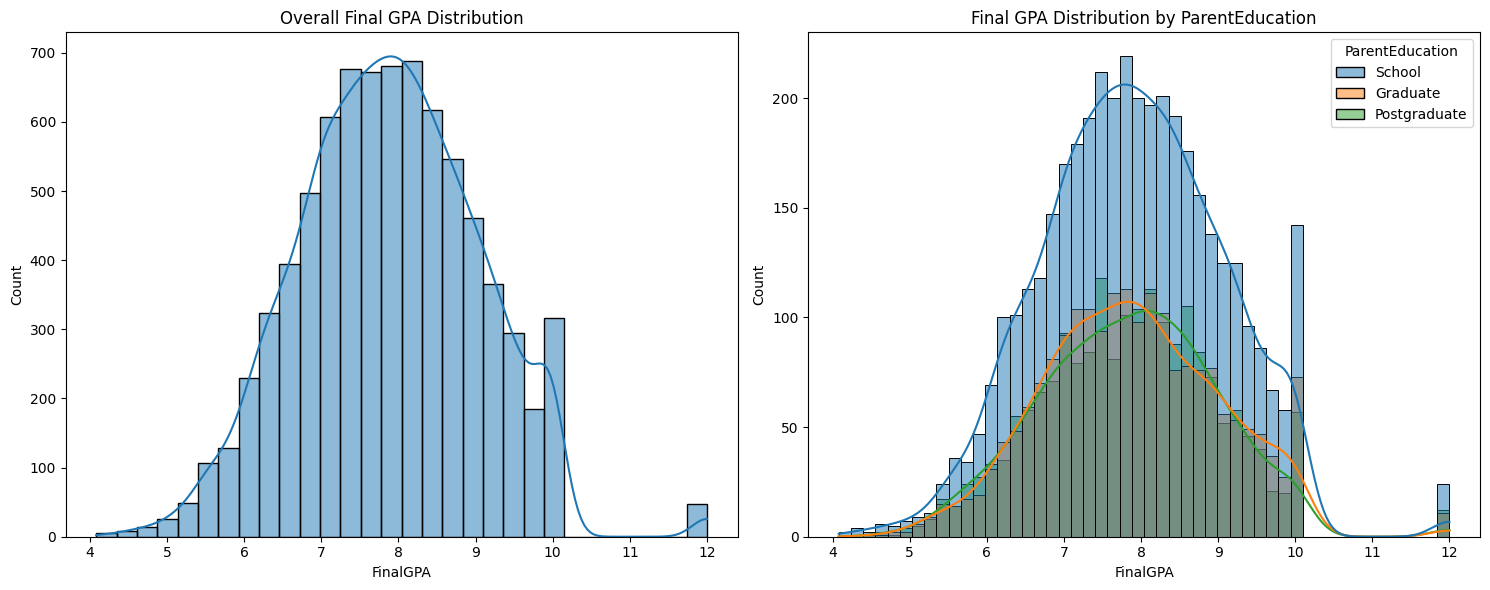

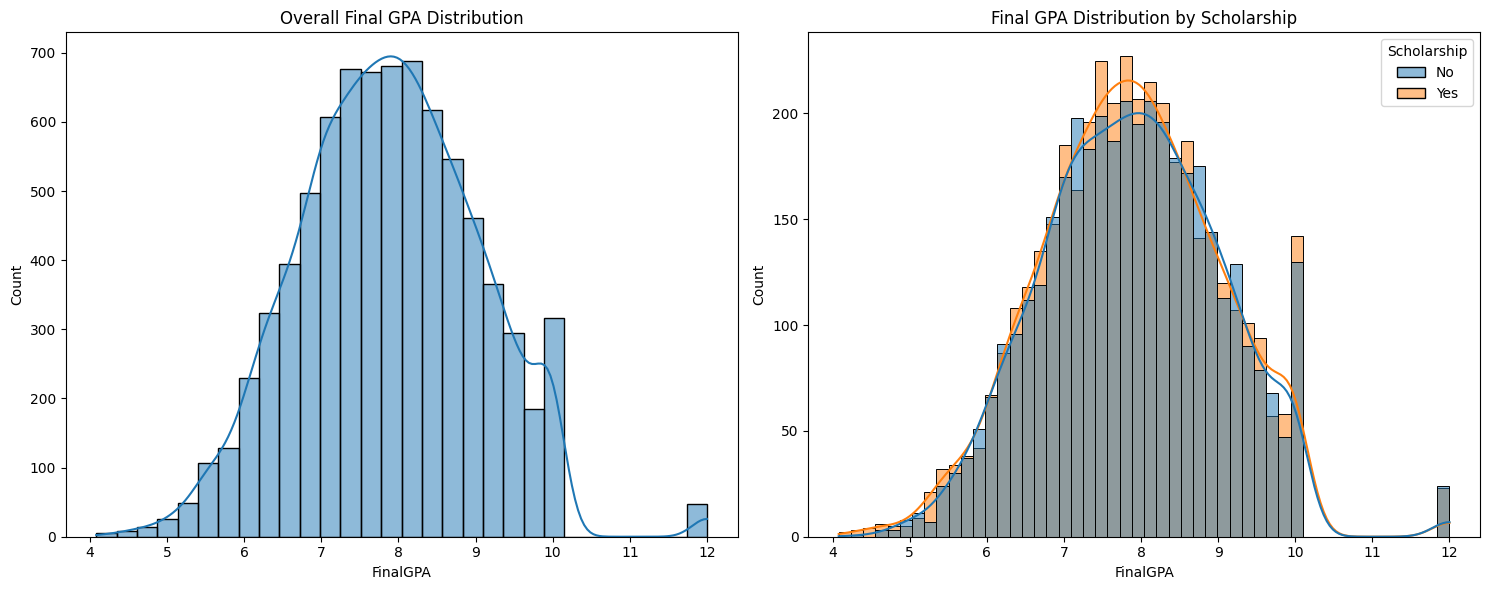

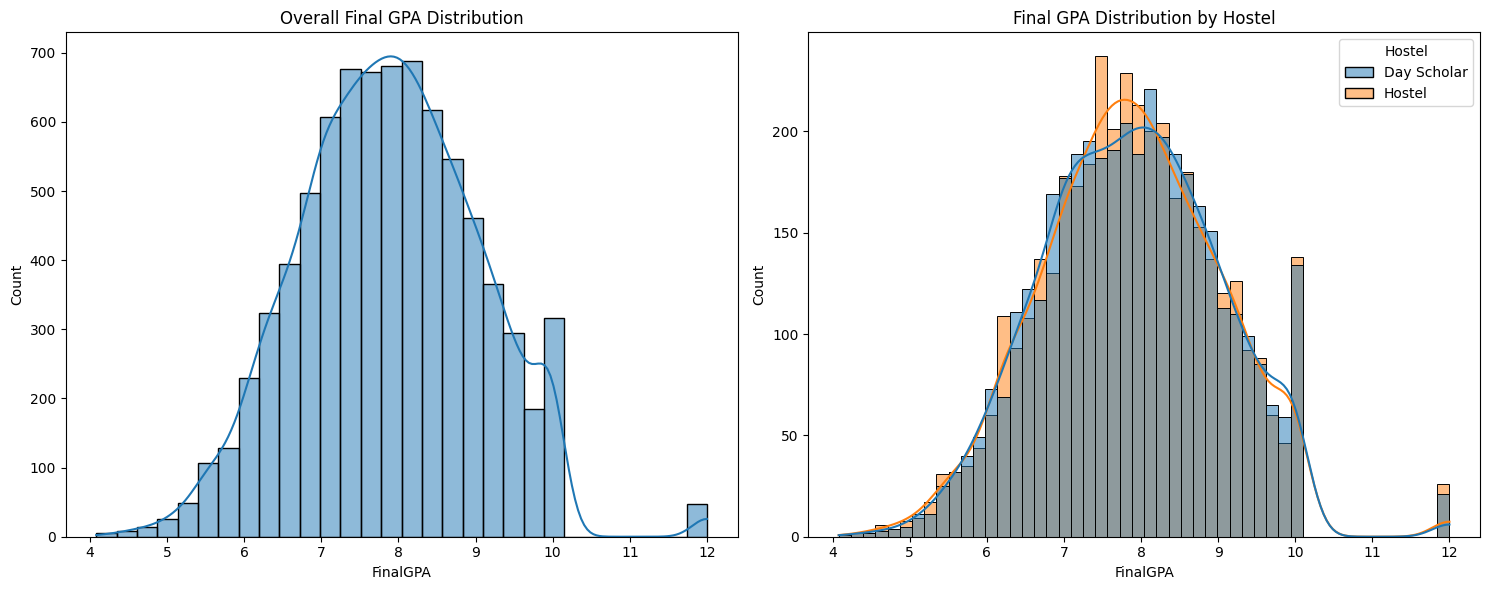

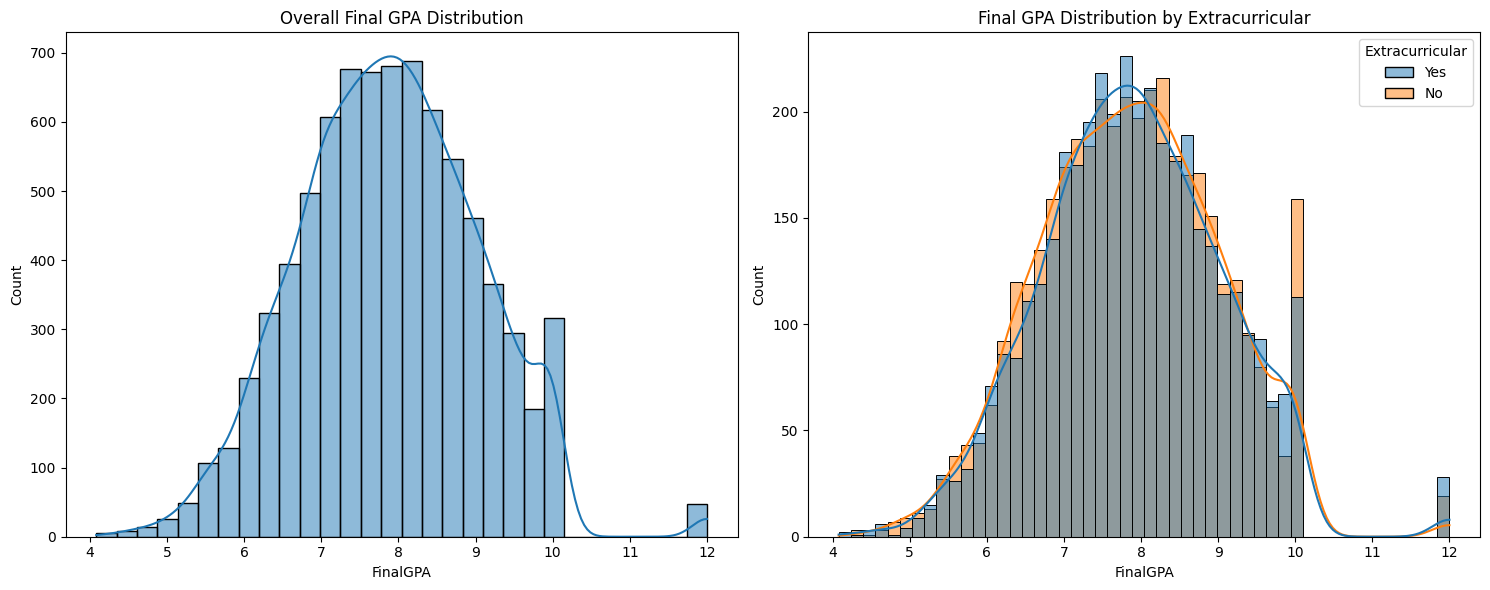

In [378]:
for col in categorical_features:

    fig, axs = plt.subplots(1, 2, figsize=(15, 6))

    # Overall FinalGPA distribution
    sns.histplot(
        data=df,
        x='FinalGPA',
        bins=30,
        kde=True,
        ax=axs[0]
    )

    axs[0].set_title("Overall Final GPA Distribution")

    # FinalGPA distribution according to categorical feature
    sns.histplot(
        data=df,
        x='FinalGPA',
        kde=True,
        hue=col,
        ax=axs[1]
    )

    axs[1].set_title(f"Final GPA Distribution by {col}")

    plt.tight_layout()
    plt.show()

In [384]:
features_col = numeric_features + categorical_features

X = df[features_col]
y = df["FinalGPA"]